In [2]:
#SAE utils

from torch import nn
from tqdm import tqdm as tqdm
import matplotlib.pyplot as plt
import sys
sys.path.append('../src')
from typing import Any
from torch.utils.data import DataLoader, TensorDataset
import torch
import numpy as np
import torch.optim as optim
from pathlib import Path
from typing import List, Tuple, Optional, Dict, Any, Union
from collections import deque
import warnings
import math
from k_sae_base_sae import SparseAutoencoder, TopKSparseAutoencoder, BatchTopKSparseAutoencoder
from scipy.optimize import linear_sum_assignment
from scipy.stats import rankdata

from sklearn.metrics.pairwise import cosine_similarity
from torch import nn
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from typing import Tuple


# --- anti-duplicate penalty on decoder atoms (columns) ---
def decoder_cosine_penalty(W: torch.Tensor, threshold: float = 0.0) -> torch.Tensor:
    # W: [input_dim, D] with atoms as columns
    Wn = W / (W.norm(dim=0, keepdim=True) + 1e-8)
    cos = Wn.T @ Wn                      # [D, D]
    off_diag = cos - torch.diag(torch.diag(cos))
    off_diag_abs = off_diag.abs()
    if threshold > 0.0:
        off_diag_abs = torch.clamp(off_diag_abs - threshold, min=0.0)
    return off_diag_abs.mean()         # encourage incoherence (small off-diagonals)


@torch.no_grad()
def duplicate_metrics(W: torch.Tensor, cos_thresh: float = 0.9):
    Wn = W / (W.norm(dim=0, keepdim=True) + 1e-8)
    cos = Wn.T @ Wn
    D = cos.shape[0]
    off = cos - torch.diag(torch.diag(cos))
    upper = torch.triu(off, diagonal=1)
    dup_pairs = (upper > cos_thresh).sum().item()
    total_pairs = D * (D - 1) // 2
    dup_ratio = dup_pairs / max(1, total_pairs)
    return dup_pairs, dup_ratio, off.abs().mean().item()


def _get_decoder_weight(sae) -> Optional[torch.Tensor]:
    candidates = [
        getattr(sae, "decoder", None),
        getattr(sae, "decode", None),
        getattr(sae, "proj_out", None),
        getattr(sae, "W_dec", None),
        getattr(sae, "W", None),
    ]
    for mod in candidates:
        if mod is None:
            continue
        if isinstance(mod, torch.Tensor):
            return mod
        if hasattr(mod, "weight"):
            return mod.weight
    return None


def _get_encoder_weight(sae) -> Optional[torch.Tensor]:
    enc = getattr(sae, "encoder", None)
    if enc is None:
        return None
    if isinstance(enc, torch.Tensor):
        return enc
    if hasattr(enc, "weight"):
        return enc.weight
    return None


def _get_encoder_bias(sae) -> Optional[torch.Tensor]:
    enc = getattr(sae, "encoder", None)
    if enc is None:
        return None
    if hasattr(enc, "bias"):
        return enc.bias
    return None


class ActivationFrequencyWindow:
    """Track per-feature activation frequency over a fixed window of steps."""

    def __init__(self, code_dim: int, window_steps: int) -> None:
        self.window_steps = max(1, int(window_steps))
        self._counts: deque[torch.Tensor] = deque()
        self._totals: deque[int] = deque()
        self._sum_counts = torch.zeros(code_dim, dtype=torch.float32)
        self._sum_total = 0

    def update(self, z: torch.Tensor, *, act_threshold: float = 0.0) -> None:
        with torch.no_grad():
            act = (z > act_threshold).float()
            counts = act.sum(dim=0).detach().cpu()
            total = int(z.shape[0])
        if len(self._counts) >= self.window_steps:
            old_counts = self._counts.popleft()
            old_total = self._totals.popleft()
            self._sum_counts -= old_counts
            self._sum_total -= old_total
        self._counts.append(counts)
        self._totals.append(total)
        self._sum_counts += counts
        self._sum_total += total

    def rates(self) -> Optional[torch.Tensor]:
        if self._sum_total <= 0:
            return None
        return self._sum_counts / float(self._sum_total)

    def ready(self) -> bool:
        return len(self._counts) >= self.window_steps


def _zero_optimizer_state_for_param(
    optimiser: optim.Optimizer,
    param: torch.nn.Parameter,
    *,
    row_idx: Optional[int] = None,
    col_idx: Optional[int] = None,
) -> None:
    state = optimiser.state.get(param)
    if not state:
        return
    for k, v in state.items():
        if not torch.is_tensor(v):
            continue
        if v.shape == param.shape:
            if row_idx is not None and col_idx is None:
                v[row_idx, ...] = 0
            elif col_idx is not None and row_idx is None:
                v[..., col_idx] = 0
            elif row_idx is not None and col_idx is not None:
                v[row_idx, col_idx] = 0
        elif v.ndim == 1 and row_idx is not None and v.shape[0] == param.shape[0]:
            v[row_idx] = 0


def _quantile_1d(x: torch.Tensor, q: float) -> torch.Tensor:
    q = float(q)
    if hasattr(torch, "quantile"):
        return torch.quantile(x, q)
    # Fallback for older torch versions
    k = max(1, int(math.ceil(q * x.numel())))
    return x.kthvalue(k).values


@torch.no_grad()
def resample_dead_features(
    sae,
    batch: torch.Tensor,
    dead_indices:Union[List[int], torch.Tensor],
    *,
    alpha: float = 1.0,
    target_activation_rate: float = 0.05,
    optimiser: Optional[optim.Optimizer] = None,
    residual_norm: str = "l2",
    per_feature_residual: bool = True,
) -> Dict[str, Any]:
    """
    Reinitialize dead features using the residual of the worst-reconstructed sample.

    Procedure (per dead unit j):
      - compute residual R = X - X_hat on a batch X
      - choose i = argmax ||R_i||
      - set decoder column j to normalized R_i
      - set encoder row j to alpha * decoder_col^T
      - set encoder bias j so activation rate on X is ~target_activation_rate
      - zero optimiser state for touched params

    If per_feature_residual is True, residuals are recomputed per feature.
    """
    if isinstance(dead_indices, torch.Tensor):
        dead_list = dead_indices.flatten().tolist()
    else:
        dead_list = list(dead_indices)
    if not dead_list:
        return {"resampled": 0}

    encW = _get_encoder_weight(sae)
    encb = _get_encoder_bias(sae)
    decW = _get_decoder_weight(sae)
    if encW is None or encb is None or decW is None:
        raise ValueError("SAE must expose encoder/decoder weights and encoder bias.")

    device = next(sae.parameters()).device
    x = batch.to(device)

    # clamp target activation rate away from extremes
    p = float(target_activation_rate)
    p = min(max(p, 1e-6), 1.0 - 1e-6)

    use_circuits = getattr(sae, "use_circuits_implementation", False)
    if use_circuits and hasattr(sae, "decoder") and hasattr(sae.decoder, "bias") and sae.decoder.bias is not None:
        x_line = x - sae.decoder.bias
    else:
        x_line = x

    def _compute_atom() -> Tuple[torch.Tensor, int]:
        recon, _ = sae(x)
        residual = x - recon
        if residual_norm == "l1":
            scores = residual.abs().sum(dim=1)
        else:
            scores = residual.pow(2).sum(dim=1)
        idx = int(torch.argmax(scores).item())
        r = residual[idx]
        r_norm = r.norm().clamp_min(1e-8)
        return (r / r_norm).detach(), idx

    sample_index = None
    atom = None
    for j in dead_list:
        if per_feature_residual or atom is None:
            atom, sample_index = _compute_atom()
        # decoder column
        decW[:, j] = atom
        # encoder row
        encW[j, :] = alpha * atom

        # bias to hit target activation rate p on this batch
        preact = x_line @ encW[j, :].t()
        q = _quantile_1d(preact, 1.0 - p)
        encb[j] = -q

        if optimiser is not None:
            _zero_optimizer_state_for_param(optimiser, encW, row_idx=j)
            _zero_optimizer_state_for_param(optimiser, encb, row_idx=j)
            _zero_optimizer_state_for_param(optimiser, decW, col_idx=j)

    return {"resampled": len(dead_list), "sample_index": sample_index}


def train_sae(
    sae,
    latent_tensor: torch.Tensor,
    *,
    epochs: int = 100,
    batch_size: int = 256,
    lr: float = 1e-3,

    # Sparsity / activation regularization:
    # For hard TopK / BatchTopK you typically keep l1_lambda=0.0.
    l1_lambda: float = 0.0,
    z_l2_lambda: float = 0.0,   # useful for TopK/BatchTopK to control activation blow-up

    # Anti-duplicate penalty controls:
    w_cos: float = 0.0,         # set >0 to enable (e.g., 1e-3)
    cos_threshold: float = 0.0, # soft margin inside cosine penalty (e.g., 0.2)

    # Metrics thresholds:
    dead_thresh: float = 1e-3,  # unit considered "dead" if active fraction < dead_thresh per epoch
    dup_cos_thresh: float = 0.9,

    device: str = "cuda" if torch.cuda.is_available() else "cpu",
    verbose_every: int = 10,

    # Dead feature resampling (disabled if resample_every <= 0)
    resample_every: int = 0,
    resample_window: int = 200,
    resample_dead_threshold: Optional[float] = None,
    resample_max_features: int = 0,
    resample_batch_size: Optional[int] = None,
    resample_alpha: float = 1.0,
    resample_target_rate: float = 0.05,
    resample_act_threshold: float = 0.0,
    resample_use_current_batch: bool = False,
    resample_residual_norm: str = "l2",
    resample_verbose: bool = False,
) -> None:
    """
    Optimise reconstruction (+ optional L1, optional z-L2, optional decoder incoherence).

    Notes:
    - For hard TopK/BatchTopK SAEs: keep l1_lambda = 0.0, optionally use z_l2_lambda > 0.
    - For plain (soft) SAEs: you may set l1_lambda > 0 to induce sparsity.
    - Dead feature resampling can be enabled with resample_every > 0.
    """
    sae.to(device)
    dataset = TensorDataset(latent_tensor)
    pin_memory = device.startswith("cuda") and not latent_tensor.is_cuda
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=False, pin_memory=pin_memory)

    criterion = nn.MSELoss(reduction="mean")
    optimiser = optim.Adam(sae.parameters(), lr=lr)

    # locate decoder weights (for cosine penalty & duplicate metrics)
    decW = _get_decoder_weight(sae)
    if w_cos > 0.0 and decW is None:
        print("[WARN] w_cos > 0 but decoder weights not found; disabling cosine penalty.")
        w_cos = 0.0

    # dead-feature resampling setup
    resample_enabled = resample_every is not None and int(resample_every) > 0
    resample_dead_threshold = dead_thresh if resample_dead_threshold is None else float(resample_dead_threshold)
    resample_window = max(1, int(resample_window))
    act_window: Optional[ActivationFrequencyWindow] = None
    resample_loader = None
    resample_iter = None
    if resample_enabled:
        encW = _get_encoder_weight(sae)
        if encW is None:
            print("[WARN] resample enabled but encoder weights not found; disabling resampling.")
            resample_enabled = False
        else:
            act_window = ActivationFrequencyWindow(encW.shape[0], resample_window)
            if not resample_use_current_batch:
                resample_bsz = batch_size if resample_batch_size is None else int(resample_batch_size)
                resample_loader = DataLoader(dataset, batch_size=resample_bsz, shuffle=True, drop_last=False, pin_memory=pin_memory)
                resample_iter = iter(resample_loader)

    N = len(loader.dataset)

    global_step = 0
    for epoch in range(epochs):
        sae.train()

        running_total = 0.0
        running_recon = 0.0
        running_l1 = 0.0
        running_zl2 = 0.0
        running_cos = 0.0

        active_counts = None
        total_seen = 0

        # Track mean L0 (avg number of active codes per sample)
        l0_sum = 0.0

        for (batch,) in loader:
            batch = batch.to(device, non_blocking=pin_memory)
            optimiser.zero_grad(set_to_none=True)

            recon, z = sae(batch)  # expect z already sparse if TopK/BatchTopK SAE

            # Reconstruction
            recon_loss = criterion(recon, batch)
            loss = recon_loss

            # Optional L1 sparsity (typically OFF for hard TopK/BatchTopK)
            if l1_lambda > 0.0:
                l1_term = z.abs().mean()
                loss = loss + l1_lambda * l1_term
            else:
                l1_term = None

            # Optional activation magnitude control (often helpful for hard gating)
            if z_l2_lambda > 0.0:
                zl2_term = (z.pow(2)).mean()
                loss = loss + z_l2_lambda * zl2_term
            else:
                zl2_term = None

            # Optional decoder cosine penalty (anti-duplicate)
            if w_cos > 0.0 and decW is not None:
                cos_pen = decoder_cosine_penalty(decW, threshold=cos_threshold)
                loss = loss + w_cos * cos_pen
            else:
                cos_pen = None

            loss.backward()
            optimiser.step()
            if hasattr(sae, "renorm_decoder_"):
                sae.renorm_decoder_()

            global_step += 1
            if resample_enabled and act_window is not None:
                act_window.update(z, act_threshold=resample_act_threshold)
                if (global_step % resample_every == 0) and act_window.ready():
                    rates = act_window.rates()
                    if rates is not None:
                        dead_idx = torch.nonzero(rates < resample_dead_threshold, as_tuple=False).flatten()
                        if dead_idx.numel() > 0:
                            if resample_max_features and dead_idx.numel() > resample_max_features:
                                perm = torch.randperm(dead_idx.numel())[:resample_max_features]
                                dead_idx = dead_idx[perm]
                            if resample_use_current_batch:
                                info = resample_dead_features(
                                    sae,
                                    batch,
                                    dead_idx,
                                    alpha=resample_alpha,
                                    target_activation_rate=resample_target_rate,
                                    optimiser=optimiser,
                                    residual_norm=resample_residual_norm,
                                )
                                if resample_verbose:
                                    print(f"[Resample] step {global_step} | resampled {info['resampled']}")
                            else:
                                try:
                                    (rbatch,) = next(resample_iter)
                                except StopIteration:
                                    resample_iter = iter(resample_loader)
                                    (rbatch,) = next(resample_iter)
                                info = resample_dead_features(
                                    sae,
                                    rbatch,
                                    dead_idx,
                                    alpha=resample_alpha,
                                    target_activation_rate=resample_target_rate,
                                    optimiser=optimiser,
                                    residual_norm=resample_residual_norm,
                                    per_feature_residual=False,
                                )
                                if resample_verbose:
                                    print(f"[Resample] step {global_step} | resampled {info.get('resampled', 0)}")

            bsz = batch.size(0)

            # Track epoch sums for averages
            running_total += loss.item() * bsz
            running_recon += recon_loss.item() * bsz

            if l1_term is not None:
                running_l1 += (l1_lambda * l1_term).item() * bsz

            if zl2_term is not None:
                running_zl2 += (z_l2_lambda * zl2_term).item() * bsz

            if cos_pen is not None:
                running_cos += (w_cos * cos_pen).item() * bsz

            # Dead% + L0 stats
            with torch.no_grad():
                act = (z > 0).float()  # [B, D] assumes ReLU-ish codes; OK for hard-gated nonneg codes
                batch_counts = act.sum(dim=0)  # [D]
                active_counts = batch_counts if active_counts is None else (active_counts + batch_counts)

                total_seen += z.shape[0]
                l0_sum += act.sum(dim=1).float().sum().item()

        # Epoch-end averages
        avg_total = running_total / N
        avg_recon = running_recon / N
        avg_l1 = running_l1 / N
        avg_zl2 = running_zl2 / N
        avg_cos = running_cos / N
        avg_l0 = l0_sum / max(1.0, float(N))

        dead_pct = 0.0
        if active_counts is not None and total_seen > 0:
            per_unit_rate = (active_counts / float(total_seen)).to(torch.float32)  # [D]
            dead_pct = (per_unit_rate < dead_thresh).float().mean().item()

        dup_pairs = dup_ratio = mean_abs_off = 0.0
        if decW is not None:
            with torch.no_grad():
                W_now = _get_decoder_weight(sae)
                if W_now is not None:
                    dup_pairs, dup_ratio, mean_abs_off = duplicate_metrics(W_now, cos_thresh=dup_cos_thresh)

        if verbose_every and ((epoch + 1) % verbose_every == 0 or epoch == 0 or epoch == epochs - 1):
            msg = (
                f"Epoch {epoch + 1:3d}/{epochs} | "
                f"total {avg_total:.10f}  recon {avg_recon:.10f}"
            )
            if l1_lambda > 0.0:
                msg += f"  l1 {avg_l1:.10f}"
            if z_l2_lambda > 0.0:
                msg += f"  zL2 {avg_zl2:.10f}"
            if w_cos > 0.0:
                msg += f"  cos_pen {avg_cos:.6f}"
            msg += f"  dead% {100*dead_pct:5.2f}  L0 {avg_l0:.3f}"
            if decW is not None:
                msg += f"  dup_pairs {dup_pairs}  dup_ratio {dup_ratio:.4f}  |offdiag| {mean_abs_off:.4f}"
            print(msg)

def save_checkpoint(
    sae: SparseAutoencoder,
    path: Path,
    meta: Optional[Dict[str, Any]] = None,
) -> None:
    """Save model + meta to a file."""
    meta = dict(meta or {})
    # Persist model type/config so load_checkpoint can restore gated variants.
    meta.setdefault("sae_type", getattr(sae, "sae_type", "sae"))
    if hasattr(sae, "k"):
        meta.setdefault("k", getattr(sae, "k"))
    if hasattr(sae, "by_abs"):
        meta.setdefault("by_abs", getattr(sae, "by_abs"))
    meta.setdefault("tied_weights", getattr(sae, "tied_weights", False))
    meta.setdefault("use_circuits_implementation", getattr(sae, "use_circuits_implementation", False))
    ckpt = {
        "state_dict": sae.state_dict(),
        "input_dim": sae.encoder.in_features,
        "code_dim": sae.encoder.out_features,
        "meta": meta,
    }
    torch.save(ckpt, Path(path))
    print(f"Checkpoint saved to {path}")


def load_checkpoint(path: Path, device: str = "cpu") -> SparseAutoencoder:
    """Load a checkpoint and return a ready-to-use model."""
    ckpt = torch.load(Path(path), map_location=device)
    meta = ckpt.get("meta") or {}
    sae_type = meta.get("sae_type") or ckpt.get("sae_type") or "sae"
    input_dim = ckpt["input_dim"]
    code_dim = ckpt["code_dim"]
    if sae_type in {"batch_top_k_sae", "batch_top_k", "BatchTopKSparseAutoencoder"}:
        model = BatchTopKSparseAutoencoder(
            input_dim=input_dim,
            code_dim=code_dim,
            k=meta.get("k", 32),
            by_abs=meta.get("by_abs", False),
            tied_weights=meta.get("tied_weights", False),
            use_circuits_implementation=meta.get("use_circuits_implementation", False),
        )
    elif sae_type in {"top_k_sae", "top_k", "TopKSparseAutoencoder"}:
        model = TopKSparseAutoencoder(
            input_dim=input_dim,
            code_dim=code_dim,
            k=meta.get("k", 32),
            tied_weights=meta.get("tied_weights", False),
            use_circuits_implementation=meta.get("use_circuits_implementation", False),
        )
    else:
        model = SparseAutoencoder(
            input_dim=input_dim,
            code_dim=code_dim,
            tied_weights=meta.get("tied_weights", False),
            use_circuits_implementation=meta.get("use_circuits_implementation", False),
        )
    model.load_state_dict(ckpt["state_dict"])
    model.to(device)
    model.eval()
    return model


def _shannon_entropy(weights: torch.Tensor) -> float:
    """Return Shannon entropy (base‑*e*) of a non‑negative weight vector."""
    tot = weights.sum()
    if tot == 0:
        return float("nan")
    probs = weights / tot
    # add epsilon to avoid log(0)
    entropy = -(probs * (probs + 1e-12).log()).sum().item()
    return entropy / math.log(2)  # convert to bits

def activation_summary_stats(
    acts : torch.Tensor,
    labels: torch.Tensor,
    *,
    threshold: float = 0.0,
    top_k: Optional[int] = None,
    device: str = "cuda" if torch.cuda.is_available() else "cpu",
) -> Dict[int, Dict[str, float]]:
    
    labels = labels.cpu()
    # Determine if labels are numeric (for std‑dev)
    numeric_labels: Optional[torch.Tensor] = None
    if labels.dtype in (torch.int8, torch.int16, torch.int32, torch.int64, torch.float32, torch.float64):
        numeric_labels = labels.float()

    N, C = acts.shape
    stats: Dict[int, Dict[str, float]] = {}

    for cid in range(C):
        z = acts[:, cid]

        # Active sample mask --------------------------------------------------
        if top_k is not None:
            # Guard against top_k > N
            k = min(top_k, N)
            idx = torch.topk(z, k, largest=True).indices
            active_mask = torch.zeros_like(z, dtype=torch.bool)
            active_mask[idx] = True
        else:
            active_mask = z > threshold
        num_active = int(active_mask.sum())
        sparsity = num_active / N

        if num_active == 0:
            stats[cid] = {
                "sparsity": sparsity,
                "mean_activation": 0.0,
                "label_entropy": float("nan"),
                "label_std": float("nan"),
            }
            continue

        pos_acts = z[active_mask]
        mean_act = float(pos_acts.mean())

        # Label entropy -------------------------------------------------------
        lbl_subset = labels[active_mask]
        uniq_lbl, inverse = lbl_subset.unique(return_inverse=True)
        sums = torch.zeros_like(uniq_lbl, dtype=torch.float)
        sums = sums.scatter_add(0, inverse, pos_acts)
        entropy = _shannon_entropy(sums)

        # Label standard deviation -------------------------------------------
        if numeric_labels is not None:
            std = float(numeric_labels[active_mask].std())
        else:
            std = float("nan")

        stats[cid] = {
            "sparsity": sparsity,
            "mean_activation": mean_act,
            "label_entropy": entropy,
            "label_std": std,
        }
    return stats


def concept_summary_stats(
    sae: "SparseAutoencoder",
    latent_tensor: torch.Tensor,
    labels: torch.Tensor,
    *,
    threshold: float = 0.0,
    top_k: Optional[int] = None,
    device: str = "cuda" if torch.cuda.is_available() else "cpu",
) -> Dict[int, Dict[str, float]]:
    """Compute Lim‑et‑al metrics for **every** concept.

    Definitions (identical to the paper):
        • *Sparsity*  = fraction of *all* samples whose activation > 0. High is common or uninterpretable.
        • *Mean activation*  = average of **positive** activation values. High is meaningful concept.
        • *Label entropy*  = Shannon entropy over labels where each label is
          weighted by the *sum* of its positive activations (Eq.(2)).
        • *Label std‑dev*  = standard deviation of **numeric** labels among
          the activated samples (NaN if labels are not numeric).

    Parameters
    ----------
    threshold : float, optional
        Minimum activation value for a sample to be considered "active" if
        *top_k* is *None*.
    top_k : int, optional
        If provided, ignore *threshold* and use the *k* highest‑activation
        samples per concept instead.
    """
    sae.eval()
    acts = sae.encode(latent_tensor.to(device)).cpu()  # (N, C)
    labels = labels.cpu()

    # Determine if labels are numeric (for std‑dev)
    numeric_labels: Optional[torch.Tensor] = None
    if labels.dtype in (torch.int8, torch.int16, torch.int32, torch.int64, torch.float32, torch.float64):
        numeric_labels = labels.float()

    N, C = acts.shape
    stats: Dict[int, Dict[str, float]] = {}

    for cid in range(C):
        z = acts[:, cid]

        # Active sample mask --------------------------------------------------
        if top_k is not None:
            # Guard against top_k > N
            k = min(top_k, N)
            idx = torch.topk(z, k, largest=True).indices
            active_mask = torch.zeros_like(z, dtype=torch.bool)
            active_mask[idx] = True
        else:
            active_mask = z > threshold
        num_active = int(active_mask.sum())
        sparsity = num_active / N

        if num_active == 0:
            stats[cid] = {
                "sparsity": sparsity,
                "mean_activation": 0.0,
                "label_entropy": float("nan"),
                "label_std": float("nan"),
            }
            continue

        pos_acts = z[active_mask]
        mean_act = float(pos_acts.mean())

        # Label entropy -------------------------------------------------------
        lbl_subset = labels[active_mask]
        uniq_lbl, inverse = lbl_subset.unique(return_inverse=True)
        sums = torch.zeros_like(uniq_lbl, dtype=torch.float)
        sums = sums.scatter_add(0, inverse, pos_acts)
        entropy = _shannon_entropy(sums)

        # Label standard deviation -------------------------------------------
        if numeric_labels is not None:
            std = float(numeric_labels[active_mask].std())
        else:
            std = float("nan")

        stats[cid] = {
            "sparsity": sparsity,
            "mean_activation": mean_act,
            "label_entropy": entropy,
            "label_std": std,
        }
    return stats


def rank_concepts(
    stats: Dict[int, Dict[str, float]],
    *,
    key: str = "label_entropy",
    top_n: int = 10,
    ascending: bool = False,
    return_scores: bool = False,
) -> List[Any]:
    """Return *top_n* concept IDs sorted by a chosen metric.

    Parameters
    ----------
    stats : dict
        Output from :func:`concept_summary_stats`.
    key : str, default "label_entropy"
        Which metric to sort on.
    ascending : bool, default False
        If *True*, smallest values rank highest.
    return_scores : bool, default False
        If *True*, return list of *(concept_id, score)* pairs; otherwise just
        the concept IDs.
    """
    if not stats:
        warnings.warn("Empty stats dictionary; returning empty list.")
        return []
    if key not in next(iter(stats.values())):
        raise KeyError(f"Metric '{key}' not found in stats dictionary")

# filter out NaNs before sorting
    valid_pairs = [
        (cid, m[key]) for cid, m in stats.items() if not math.isnan(m[key])
    ]
    if not valid_pairs:
        warnings.warn(f"All values are NaN for metric '{key}'.")
        return []

    ranked_pairs = sorted(valid_pairs, key=lambda kv: kv[1], reverse=not ascending)
    ranked_pairs = ranked_pairs[:top_n]
    return ranked_pairs if return_scores else [cid for cid, _ in ranked_pairs]

def query_concepts(
    stats: Dict[int, Dict[str, float]],
    *,
    bounds: Dict[str, Tuple[Optional[float], Optional[float]]],
    sort_key: Optional[str] = None,
    ascending: bool = True,
    return_scores: bool = False,
) -> List[Any]:
    """Filter concepts using **multiple metric ranges**.

    Parameters
    ----------
    stats : dict
        Output dictionary from :func:`concept_summary_stats`.
    bounds : dict
        Mapping ``metric_name -> (lower, upper)`` where *lower* or *upper* can
        be *None* to leave that side unbounded.  Example::

            bounds = {
                "sparsity": (None, 0.05),          # sparsity ≤ 5%
                "label_entropy": (None, 1.0),      # entropy ≤ 1 bit
                "mean_activation": (1e-3, None),   # mean_act ≥ 1e-3
            }
    sort_key : str, optional
        Metric to sort by.  Defaults to the first key in ``bounds``.
    ascending : bool, default True
        Sort order (ignored if *sort_key* is *None*).
    return_scores : bool, default False
        If *True* return list of ``(concept_id, metric_dict)``; otherwise just
        the concept IDs.
    """
    if not bounds:
        raise ValueError("bounds dict cannot be empty.")
    for k in bounds:
        if k not in next(iter(stats.values())):
            raise KeyError(f"Metric '{k}' not found in stats dictionary.")

    def in_range(val: float, lo: Optional[float], hi: Optional[float]) -> bool:
        if math.isnan(val):
            return False
        if lo is not None and val < lo:
            return False
        if hi is not None and val > hi:
            return False
        return True

    selected: List[Tuple[int, Dict[str, float]]] = []
    for cid, m in stats.items():
        if all(in_range(m[k], *bounds[k]) for k in bounds):
            selected.append((cid, m))

    if sort_key is None:
        sort_key = next(iter(bounds))  # first metric key

    selected.sort(key=lambda kv: kv[1][sort_key], reverse=not ascending)
    return (
        [(cid, mdict) for cid, mdict in selected]
        if return_scores
        else [cid for cid, _ in selected]
    )


def plot_metrics_figure(
    stats: Dict[int, Dict[str, float]],
    *,
    figsize: Tuple[int, int] = (10, 7),
    cmap: str = "plasma",
    show: bool = True,
    save_path: Optional[Path] = None,
    shapes = None
) -> None:
    """Replicate Lim‑et‑al style figure.

    Scatter of log10 Activated Frequency (x) vs log10 Mean Activation (y),
    colour‑coded by Label Entropy, with marginal histograms.
    """
    # Assemble data -----------------------------------------------------
    cids = []
    freq = []
    mean_act = []
    ent = []
    for cid, m in stats.items():
        if any(math.isnan(m[k]) for k in ("sparsity", "mean_activation", "label_entropy")):
            continue
        # Skip zero activations to avoid -inf
        if m["sparsity"] <= 0 or m["mean_activation"] <= 0:
            continue
        cids.append(cid)
        freq.append(m["sparsity"])
        mean_act.append(m["mean_activation"])
        ent.append(m["label_entropy"])

    if not cids:
        warnings.warn("No finite data to plot.")
        return

    freq = np.log10(np.array(freq))
    mean_act = np.log10(np.array(mean_act))
    ent = np.array(ent)

    # Figure layout -----------------------------------------------------
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 2, width_ratios=[5, 1.2], height_ratios=[1.2, 5], hspace=0.05, wspace=0.05)
    ax_histx = fig.add_subplot(gs[0, 0])
    ax_histy = fig.add_subplot(gs[1, 1])
    ax_scatter = fig.add_subplot(gs[1, 0])

    # Main scatter ------------------------------------------------------
    if shapes == None:
        shapes = ["."]*len(stats)
    #sc = ax_scatter.scatter(freq, mean_act, c=ent, cmap=cmap, s=10, alpha=0.8,marker=shapes)
    for lab in np.unique(shapes):
        idx = (np.array(shapes)[cids] == lab)
        sc = ax_scatter.scatter(freq[idx], mean_act[idx], c=ent[idx], cmap=cmap, marker=lab, s=20, alpha=0.8)

    ax_scatter.set_xlabel("Log Activated Frequency")
    ax_scatter.set_ylabel("Log Mean Activation Value")
    ax_scatter.grid(True, linestyle="--", alpha=0.3)

    # Marginal histograms ----------------------------------------------
    ax_histx.hist(freq, bins=60, color="steelblue")
    ax_histy.hist(mean_act, bins=60, orientation="horizontal", color="steelblue")
    ax_histx.axis("off")
    ax_histy.axis("off")

    # Colorbar ----------------------------------------------------------
    cbar = fig.colorbar(sc, ax=[ax_scatter, ax_histy,ax_histx], pad=0.01, label="Label Entropy (bits)")

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Metrics figure saved → {save_path}")
    if show:
        plt.show()
    else:
        plt.close(fig)

def most_activated_indices(
    sae: SparseAutoencoder,
    latent_tensor: torch.Tensor,
    concept_idx: int,
    *,
    k: int = 25,
    device: str = "cuda" if torch.cuda.is_available() else "cpu",
    bottom = False
) -> Tuple[torch.Tensor, torch.Tensor]:
    sae.eval()
    largest = not bottom
    with torch.no_grad():
        codes = sae.encode(latent_tensor.to(device))
        activations = codes[:, concept_idx].cpu()
        k_eff = max(1, min(int(k), activations.numel()))
        topk = torch.topk(activations, k_eff, largest=largest, sorted=True)
    return topk.indices, topk.values


def _topk_similarity_matrix(
    acts_a: torch.Tensor,
    acts_b: torch.Tensor,
    *,
    k: int = 50,
    metric: str = "jaccard",
    threshold: Optional[float] = None,
    act_threshold: float = 0.0,
    device: str = "cuda" if torch.cuda.is_available() else "cpu",
    **kwargs,
) -> np.ndarray:
    """
    Compare two activation matrices by overlap of per-concept top-k active samples.
    Returns a dense [Da, Db] similarity matrix.
    """
    if metric not in {"jaccard", "overlap"}:
        raise ValueError("metric must be 'jaccard' or 'overlap'.")

    a = _to_numpy(acts_a)
    b = _to_numpy(acts_b)
    if a.ndim != 2 or b.ndim != 2:
        raise ValueError("acts_a and acts_b must be 2D arrays [N, D].")
    if a.shape[0] != b.shape[0]:
        raise ValueError("acts_a and acts_b must have the same number of rows (N).")

    n, da = a.shape
    _, db = b.shape
    k_eff = max(1, min(int(k), n))

    def _membership(x: np.ndarray) -> np.ndarray:
        m = np.zeros((n, x.shape[1]), dtype=np.uint8)
        for j in range(x.shape[1]):
            vals = x[:, j]
            active_idx = np.flatnonzero(vals > act_threshold)
            if active_idx.size == 0:
                continue
            if active_idx.size > k_eff:
                active_vals = vals[active_idx]
                top_local = np.argpartition(active_vals, -k_eff)[-k_eff:]
                idx = active_idx[top_local]
            else:
                idx = active_idx
            m[idx, j] = 1
        return m

    mem_a = _membership(a)
    mem_b = _membership(b)

    inter = mem_a.T.astype(np.int32) @ mem_b.astype(np.int32)
    sizes_a = mem_a.sum(axis=0, dtype=np.int32)[:, None]
    sizes_b = mem_b.sum(axis=0, dtype=np.int32)[None, :]

    if metric == "jaccard":
        denom = sizes_a + sizes_b - inter
    else:
        denom = np.minimum(sizes_a, sizes_b)

    scores = np.divide(inter, denom, out=np.zeros_like(inter, dtype=np.float32), where=denom > 0)
    return scores.astype("float16")


def most_activated_images(image_paths: List[Path], indices: torch.Tensor) -> List[Path]:
    return [image_paths[i] for i in indices]


def _to_numpy(x: Any) -> np.ndarray:
    if isinstance(x, np.ndarray):
        return x
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def _rank_transform_cols(x: np.ndarray) -> np.ndarray:
    ranked = np.zeros_like(x, dtype=float)
    for j in range(x.shape[1]):
        ranked[:, j] = rankdata(x[:, j], method="average")
    return ranked


def _corr_similarity_matrix(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    a = a - a.mean(axis=0, keepdims=True)
    b = b - b.mean(axis=0, keepdims=True)
    denom_a = np.sqrt((a * a).sum(axis=0, keepdims=True))
    denom_b = np.sqrt((b * b).sum(axis=0, keepdims=True))
    denom = (denom_a.T @ denom_b)
    denom = np.where(denom == 0, 1.0, denom)
    sim = (a.T @ b) / denom
    sim = np.clip(sim, -1.0, 1.0)
    return sim.astype('float16')

def _cos_similarity_matrix(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    a = a - a.mean(axis=0, keepdims=True)
    b = b - b.mean(axis=0, keepdims=True)
    sim = cosine_similarity(a.T,b.T)
    return sim.astype('float16')

def _get_random_similarity_matrix(
    a: np.ndarray,
    b: np.ndarray,
    method: str = "cos",
    N: int = 10,
    fixed_sae: bool = False,
    rng: Optional[np.random.Generator] = None,
):
    rng = np.random.default_rng() if rng is None else rng
    max_similarities = np.zeros(a.shape[1], dtype=np.float32)
    a_perm = a.copy()
    for _ in range(N):
        perm = rng.permutation(a_perm.shape[0])
        a_perm = a_perm[perm]
        if method == "cos":
            max_sim = _cos_similarity_matrix(a_perm, b)
        else:
            max_sim = _corr_similarity_matrix(a_perm, b)

        if fixed_sae:
            max_similarities += np.diag(max_sim)
        else:
            max_similarities += max_sim.max(0)

    return (max_similarities / max(1, N)).astype("float16")


def _hungarian_from_similarity(
    sim: np.ndarray,
    *,
    allow_unmatched: bool,
    dummy_sim: float,
    min_sim: Optional[float],
) -> Tuple[np.ndarray, np.ndarray]:
    da, db = sim.shape
    if allow_unmatched:
        size = max(da, db)
        sim_pad = np.full((size, size), dummy_sim, dtype=float)
        sim_pad[:da, :db] = sim
        cost = -sim_pad
        row_ind, col_ind = linear_sum_assignment(cost)
        match_ids = np.full(da, -1, dtype=int)
        match_scores = np.full(da, dummy_sim, dtype=float)
        for r, c in zip(row_ind, col_ind):
            if r < da:
                if c < db and (min_sim is None or sim_pad[r, c] >= min_sim):
                    match_ids[r] = c
                    match_scores[r] = sim_pad[r, c]
    else:
        cost = -sim
        row_ind, col_ind = linear_sum_assignment(cost)
        match_ids = np.full(da, -1, dtype=int)
        match_scores = np.full(da, np.nan, dtype=float)
        for r, c in zip(row_ind, col_ind):
            match_ids[r] = c
            match_scores[r] = sim[r, c]
        if min_sim is not None:
            low = match_scores < min_sim
            match_ids[low] = -1
    return match_ids, match_scores

#def align_concepts_max(


#):


def align_concepts_hungarian(
    sim: np.array,
    *,
    rank_transform: Optional[bool] = None,
    zscore: bool = True,
    allow_unmatched: bool = True,
    dummy_sim: float = 0.0,
    min_sim: Optional[float] = 0.2,
    thresholds: Tuple[float, float] = (0.7, 0.4),
    **kwargs
) -> Dict[str, Any]:
    """
    Align concepts across two activation matrices using Hungarian matching.

    acts_a/acts_b are activation matrices with shape [N, D].
    """
    da, db = sim.shape

    match_ids, match_scores = _hungarian_from_similarity(
        sim,
        allow_unmatched=allow_unmatched,
        dummy_sim=dummy_sim,
        min_sim=min_sim,
    )

    matched_mask = match_ids >= 0
    matched_scores = match_scores[matched_mask]
    if matched_scores.size:
        median = float(np.median(matched_scores))
        q1 = float(np.percentile(matched_scores, 25))
        q3 = float(np.percentile(matched_scores, 75))
    else:
        median = q1 = q3 = float("nan")

    summary = {
        "mean_matched": float(np.mean(matched_scores)) if matched_scores.size else float("nan"),
        "median_matched": median,
        "iqr_matched": float(q3 - q1) if matched_scores.size else float("nan"),
        "matched_fraction": float(matched_mask.mean()) if match_ids.size else float("nan"),
    }
    for t in thresholds:
        summary[f"frac_ge_{t}"] = float(np.mean(matched_scores >= t)) if matched_scores.size else float("nan")

    out = {
        "match_ids": match_ids,
        "match_scores": match_scores,
        "summary": summary,
    }
    return out


def get_saes_similarities(
    sae_a: SparseAutoencoder,
    latent_tensor_a: torch.Tensor,
    acts_b: torch.Tensor,
    fixed_sae: bool = False,
    metric = "jaccard",
    method = "spearman",
    random_state: Optional[int] = None,
    rank_transform: Optional[bool] = None,
    zscore: bool = False,
    *,
    device: str = "cuda" if torch.cuda.is_available() else "cpu",
    **kwargs: Any,
) -> Dict[str, Any]:
    sae_a.eval()
    with torch.no_grad():
        acts_a = sae_a.encode(latent_tensor_a.to(device)).cpu()

    rng = np.random.default_rng(random_state)

    a = _to_numpy(acts_a)
    b = _to_numpy(acts_b)

    sim_cos = _cos_similarity_matrix(a.copy(), b.copy())
    random_cos = _get_random_similarity_matrix(a.copy(), b.copy(), method="cos", N=50, fixed_sae=fixed_sae, rng=rng)

    sim_topk = _topk_similarity_matrix(a, b, metric=metric, **kwargs)
    if a.ndim != 2 or b.ndim != 2:
        raise ValueError("acts_a and acts_b must be 2D arrays [N, D].")
    if a.shape[0] != b.shape[0]:
        raise ValueError("acts_a and acts_b must have the same number of rows (N).")

    if method not in {"spearman", "pearson"}:
        raise ValueError("method must be 'spearman' or 'pearson'.")

    if rank_transform is None:
        rank_transform = (method == "spearman")

    if rank_transform:
        a_use = _rank_transform_cols(a.copy())
        b_use = _rank_transform_cols(b.copy())
    else:
        a_use = a.copy()
        b_use = b.copy()

    if zscore:
        a_use = (a_use - a_use.mean(axis=0, keepdims=True)) / (a_use.std(axis=0, keepdims=True) + 1e-12)
        b_use = (b_use - b_use.mean(axis=0, keepdims=True)) / (b_use.std(axis=0, keepdims=True) + 1e-12)

    sim_corr = _corr_similarity_matrix(a_use.copy(), b_use.copy())
    random_corr = _get_random_similarity_matrix(a_use.copy(), b_use.copy(), method="cor", N=50, fixed_sae=fixed_sae, rng=rng)
    #hungarian_res = align_concepts_hungarian(sim_corr, **kwargs)
    return {"cos_sim" : sim_cos, "cor_sim" : sim_corr, "topk_sim" : sim_topk,
     "cos_random":random_cos, "cor_random" : random_corr}


def plot_dictionary_atoms(
    sae: SparseAutoencoder,
    *,
    num_atoms: int = 16,
    atoms_per_row: int = 4,
    figsize: Tuple[int, int] = (10, 6),
    save_path: Optional[Path] = None,
    atom_indexes_bool = False,
    atom_indexes = None
) -> None:
    """Visualise selected dictionary atoms (decoder columns) as 1‑D bar plots."""
    
    decW = _get_decoder_weight(sae)
    if decW is None:
        raise ValueError("Could not find decoder weight matrix for this SAE.")
    num_atoms = min(num_atoms, int(decW.shape[1]))
    cols = atoms_per_row
    rows = math.ceil(num_atoms / cols)
    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    for i in range(num_atoms):
        r, c = divmod(i, cols)
        if atom_indexes_bool:
            i = atom_indexes[i]

        atom = sae.concept_vector(i).cpu().numpy()
        axes[r][c].bar(range(len(atom)), atom)
        axes[r][c].set_title(f"Atom {i}")
        axes[r][c].set_xticks([])
    for ax in axes.flat[num_atoms:]:
        ax.axis("off")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150)
        print(f"Dictionary figure saved to {save_path}")
    else:
        plt.show()


def plot_top_k_images(
    image_paths: List[Path],
    data,
    *,
    cols: int = 5,
    figsize: Tuple[int, int] = (12, 6),
    save_path: Optional[Path] = None,
    top_act = None,
    stats = None,
    neuron_nr = None
) -> None:
    """Display the images corresponding to the given indices in a grid."""
    paths = []
    for name in image_paths:
        p = int(name.split("/")[2].split("_")[0])
        paths.append(p)
    rows = math.ceil(len(paths) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)

    for idx, p in enumerate(paths):
        r, c = divmod(idx, cols)
        try:
            img = data[p]
            axes[r][c].imshow(img)
            axes[r][c].set_title( str(np.round(top_act[idx],5)), fontsize=8)
            axes[r][c].axis("off")
        except Exception as e:
            axes[r][c].text(0.5, 0.5, f"Error:\n{e}", ha="center", va="center")
            axes[r][c].axis("off")
    # hide any empty axes
    for ax in axes.flat[len(paths):]:
        ax.axis("off")

    plt.suptitle(f'Sparse Neuron {neuron_nr}, sparsity: {np.round(stats["sparsity"],2)}, mean_act: {np.round(stats["mean_activation"],2)}, entropy: {np.round(stats["label_entropy"],2)}')
    plt.tight_layout()


    if save_path is not None:
        plt.savefig(save_path, dpi=150)
        print(f"Image grid saved to {save_path}")
    else:
        plt.show()


In [3]:
from torch import nn
import torch
import torch.nn.functional as F
from typing import Tuple, Optional

class UnitNormDecoder(nn.Linear):
    @torch.no_grad()
    def renorm_(self) -> None:
        self.weight.div_(self.weight.norm(dim=0, keepdim=True).clamp_min_(1e-8))

    def forward(self, x):
        return super().forward(x)


class TiedDecoder(nn.Module):
    def __init__(self, encoder: nn.Linear, output_dim: int) -> None:
        super().__init__()
        self.encoder = encoder
        self.bias = nn.Parameter(torch.zeros(output_dim))

    @property
    def weight(self) -> torch.Tensor:
        return self.encoder.weight.t()

    @torch.no_grad()
    def renorm_(self) -> None:
        self.encoder.weight.div_(self.encoder.weight.norm(dim=1, keepdim=True).clamp_min_(1e-8))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.linear(x, self.weight, self.bias)
class SparseAutoencoder(nn.Module):
    """Two‑layer sparse auto‑encoder for 512‑D latent vectors with an over‑complete
    hidden "concept" layer. The decoder weights constitute the learned
    dictionary atoms.
    """
    def __init__(
        self,
        input_dim: int = 512,
        code_dim: int = 2048,
        activation: nn.Module = nn.ReLU(),
        tied_weights: bool = False,
        use_circuits_implementation: bool = False,
        sae_type = "sae"
    ) -> None:
        super().__init__()
        self.encoder = nn.Linear(input_dim, code_dim, bias=True)
        self.tied_weights = tied_weights
        self.decoder = TiedDecoder(self.encoder, input_dim) if tied_weights else UnitNormDecoder(code_dim, input_dim, bias=True)
        self.activation = activation
        self.use_circuits_implementation = use_circuits_implementation
        self.sae_type = sae_type

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        if self.use_circuits_implementation:
            x_line = x - self.decoder.bias
            z = self.activation(self.encoder(x_line))
            x_hat = self.decoder(z)
        else:
            z = self.activation(self.encoder(x))
            x_hat = self.decoder(z)
        return x_hat, z

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            if self.use_circuits_implementation:
                x = x - self.decoder.bias
            return self.activation(self.encoder(x))

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            return self.decoder(z)

    @torch.no_grad()
    def renorm_decoder_(self) -> None:
        if hasattr(self.decoder, "renorm_"):
            self.decoder.renorm_()

    def concept_vector(self, concept_idx: int) -> torch.Tensor:
        return self.decoder.weight[:, concept_idx].detach().clone()


def _topk_mask_per_row(z: torch.Tensor, k: int) -> torch.Tensor:
    """
    z: [B, D]
    Returns mask: [B, D] with exactly k True per row (unless k>=D).
    """
    B, D = z.shape
    kk = min(k, D)
    if kk <= 0:
        return torch.zeros_like(z, dtype=torch.bool)
    idx = torch.topk(z, kk, dim=1, largest=True, sorted=False).indices  # [B, kk]
    mask = torch.zeros_like(z, dtype=torch.bool)
    mask.scatter_(1, idx, True)
    return mask


def _batchtopk_mask_flat(z: torch.Tensor, k_per_sample: int, by_abs: bool = False) -> torch.Tensor:
    """
    Canonical BatchTopK:
      - z: [B, D]
      - keep top (B * k_per_sample) activations across the ENTIRE batch (flattened)
      - returns mask: [B, D] with exactly B*k True (unless truncated by size)

    by_abs=False matches "by value" selection as described in the BatchTopK SAE paper.
    by_abs=True selects by magnitude, useful if you allow signed codes.
    """
    if z.dim() != 2:
        raise ValueError(f"Expected z to have shape [B, D], got {tuple(z.shape)}")

    B, D = z.shape
    total = B * D
    K = int(k_per_sample) * B
    K = max(0, min(K, total))

    mask_flat = torch.zeros(total, device=z.device, dtype=torch.bool)
    if K == 0:
        return mask_flat.view(B, D)

    scores = z.abs() if by_abs else z
    flat_scores = scores.reshape(-1)

    # Exact-K selection via indices (avoids threshold tie issues)
    idx = torch.topk(flat_scores, K, largest=True, sorted=False).indices
    mask_flat[idx] = True
    return mask_flat.view(B, D)


class TopKSparseAutoencoder(SparseAutoencoder):
    """
    Per-sample TopK gating: exactly k non-zeros in z per example (post-activation).
    """
    def __init__(self, *args, k: int = 32, **kwargs) -> None:
        super().__init__(*args, **kwargs)
        self.k = k
        self.sae_type = "top_k_sae"

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        if self.use_circuits_implementation:
            x_line = x - self.decoder.bias
            z = self.activation(self.encoder(x_line))
        else:
            z = self.activation(self.encoder(x))

        mask = _topk_mask_per_row(z, self.k)
        z_sparse = z * mask.to(z.dtype)

        x_hat = self.decoder(z_sparse)
        return x_hat, z_sparse

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            if self.use_circuits_implementation:
                x = x - self.decoder.bias
            z = self.activation(self.encoder(x))
            mask = _topk_mask_per_row(z, self.k)
            return z * mask.to(z.dtype)


class BatchTopKSparseAutoencoder(SparseAutoencoder):
    """
    Canonical BatchTopK SAE:
    keep top (B*k) activations across the flattened batch => average k active per sample.
    """
    def __init__(self, *args, k: int = 32, by_abs: bool = False, **kwargs) -> None:
        super().__init__(*args, **kwargs)
        self.k = k
        self.by_abs = by_abs
        self.sae_type = "batch_top_k_sae"

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        if self.use_circuits_implementation:
            x_line = x - self.decoder.bias
            z = self.activation(self.encoder(x_line))
        else:
            z = self.activation(self.encoder(x))

        mask = _batchtopk_mask_flat(z, self.k, by_abs=self.by_abs)
        z_sparse = z * mask.to(z.dtype)

        x_hat = self.decoder(z_sparse)
        return x_hat, z_sparse

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            if self.use_circuits_implementation:
                x = x - self.decoder.bias
            z = self.activation(self.encoder(x))
            mask = _batchtopk_mask_flat(z, self.k, by_abs=self.by_abs)
            z_sparse = z * mask.to(z.dtype)
            return z_sparse
  

In [4]:
import numpy as np
from scipy.optimize import minimize 
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt

def softmax(x):
    """
    Compute softmax values for each sets of scores in x.
    
    Parameters:
        x (numpy.ndarray): array containing m samples with n-dimensions (m,n)
    Returns:
        x_softmax (numpy.ndarray) softmaxed values for initial (m,n) array
    """
    e_x = np.exp(x - np.max(x))  # Subtract max so biggest is 0 to avoid numerical instability
    
    # Axis 0 if only one dimensional array
    axis = 0 if len(e_x.shape) == 1 else 1
    
    return e_x / e_x.sum(axis=axis, keepdims=1)

def sigmoid(x):
    e_x = np.exp(x - np.max(x))  # Subtract max so biggest is 0 to avoid numerical instabilit
    return 1/(1+ e_x)

class HistogramBinning():
    """
    Histogram Binning as a calibration method. The bins are divided into equal lengths.
    
    The class contains two methods:
        - fit(probs, true), that should be used with validation data to train the calibration model.
        - predict(probs), this method is used to calibrate the confidences.
    """
    
    def __init__(self, M=15):
        """
        M (int): the number of equal-length bins used
        """
        self.bin_size = 1./M  # Calculate bin size
        self.conf = []  # Initiate confidence list
        self.upper_bounds = np.arange(self.bin_size, 1+self.bin_size, self.bin_size)  # Set bin bounds for intervals

    
    def _get_conf(self, conf_thresh_lower, conf_thresh_upper, probs, true):
        """
        Inner method to calculate optimal confidence for certain probability range
        
        Params:
            - conf_thresh_lower (float): start of the interval (not included)
            - conf_thresh_upper (float): end of the interval (included)
            - probs : list of probabilities.
            - true : list with true labels, where 1 is positive class and 0 is negative).
        """

        # Filter labels within probability range
        filtered = [x[0] for x in zip(true, probs) if x[1] > conf_thresh_lower and x[1] <= conf_thresh_upper]
        nr_elems = len(filtered)  # Number of elements in the list.

        if nr_elems < 1:
            return 0
        else:
            # In essence the confidence equals to the average accuracy of a bin
            conf = sum(filtered)/nr_elems  # Sums positive classes
            return conf
    

    def fit(self, probs, true):
        """
        Fit the calibration model, finding optimal confidences for all the bins.
        
        Params:
            probs: probabilities of data
            true: true labels of data
        """

        conf = []

        # Got through intervals and add confidence to list
        for conf_thresh in self.upper_bounds:
            temp_conf = self._get_conf((conf_thresh - self.bin_size), conf_thresh, probs = probs, true = true)
            conf.append(temp_conf)

        self.conf = conf


    # Fit based on predicted confidence
    def predict(self, probs):
        """
        Calibrate the confidences
        
        Param:
            probs: probabilities of the data (shape [samples, classes])
            
        Returns:
            Calibrated probabilities (shape [samples, classes])
        """

        # Go through all the probs and check what confidence is suitable for it.
        for i, prob in enumerate(probs):
            idx = np.searchsorted(self.upper_bounds, prob)
            probs[i] = self.conf[idx]

        return probs
        
        
class TemperatureScaling():
    
    def __init__(self, temp = 1, maxiter = 50, solver = "BFGS"):
        """
        Initialize class
        
        Params:
            temp (float): starting temperature, default 1
            maxiter (int): maximum iterations done by optimizer, however 8 iterations have been maximum.
        """
        self.temp = temp
        self.maxiter = maxiter
        self.solver = solver
    		
    
    def _loss_fun(self, x, probs, true, sig = False):
        # Calculates the loss using log-loss (cross-entropy loss)
        scaled_probs = self.predict(probs, x, sig)    
        loss = log_loss(y_true=true, y_pred=scaled_probs)
        return loss
    
    # Find the temperature
    def fit(self, logits, true, sig = False):
        """
        Trains the model and finds optimal temperature
        
        Params:
            logits: the output from neural network for each class (shape [samples, classes])
            true: one-hot-encoding of true labels.
            
        Returns:
            the results of optimizer after minimizing is finished.
        """
        
        true = true.flatten() # Flatten y_val
        opt = minimize(self._loss_fun, x0 = 1, args=(logits, true, sig), options={'maxiter':self.maxiter}, method = self.solver)
        self.temp = opt.x[0]
        
        return opt
        
    def predict(self, logits, temp = None, sig = False):
        """
        Scales logits based on the temperature and returns calibrated probabilities
        
        Params:
            logits: logits values of data (output from neural network) for each class (shape [samples, classes])
            temp: if not set use temperatures find by model or previously set.
            
        Returns:
            calibrated probabilities (nd.array with shape [samples, classes])
        """
        if sig == True:

            if not temp:
                #print("Cal. temperature is", self.temp)
                return sigmoid(logits/self.temp)
            else:
                return sigmoid(logits/temp)
        else:
            if not temp:
                #print("Cal. temperature is", self.temp)
                return softmax(logits/self.temp)
            else:
                return softmax(logits/temp)

            
class VectorScaling():
    
    def __init__(self, classes = 1, W = [], bias = [], maxiter = 100, solver = "BFGS", use_bias = True):
        """
        Initialize class
        
        Params:
            temp (float): starting temperature, default 1
            maxiter (int): maximum iterations done by optimizer, however 8 iterations have been maximum.
            classes (int): how many classes in given data set. (based on logits )
            W (np.ndarray): matrix with temperatures for all the classes
            bias ( np.array): vector with biases
        """
        
        self.W = W
        self.bias = bias 
        self.maxiter = maxiter
        self.solver = solver
        self.classes = classes
        self.use_bias = use_bias
    
    def _loss_fun(self, x, logits, true):
        # Calculates the loss using log-loss (cross-entropy loss)
        W = np.diag(x[:self.classes])
        
        if self.use_bias:
            bias = x[self.classes:]
        else:
            bias = np.zeros(self.classes)
        scaled_probs = self.predict(logits, W, bias)    
        loss = log_loss(y_true=true, y_pred=scaled_probs)
        return loss
    
    # Find the temperature
    def fit(self, logits, true):
        """
        Trains the model and finds optimal temperature
        
        Params:
            logits: the output from neural network for each class (shape [samples, classes])
            true: one-hot-encoding of true labels.
            
        Returns:
            the results of optimizer after minimizing is finished.
        """
        
        true = true.flatten() # Flatten y_val
        self.classes = logits.shape[1]
        x0 = np.concatenate([np.repeat(1, self.classes), np.repeat(0, self.classes)])
        opt = minimize(self._loss_fun, x0 = x0, args=(logits, true), options={'maxiter':self.maxiter}, method = self.solver)
        self.W = np.diag(opt.x[:logits.shape[1]])
        self.bias = opt.x[logits.shape[1]:]
        
        return opt
        
    def predict(self, logits, W = [], bias = []):
        """
        Scales logits based on the temperature and returns calibrated probabilities
        
        Params:
            logits: logits values of data (output from neural network) for each class (shape [samples, classes])
            temp: if not set use temperatures find by model or previously set.
            
        Returns:
            calibrated probabilities (nd.array with shape [samples, classes])
        """
        
        if len(W) == 0 or len(bias) == 0:  # Use class variables
            scaled_logits = np.dot(logits, self.W) + self.bias
        else:  # Take variables W and bias from arguments
            scaled_logits = np.dot(logits, W) + bias
        
        return scaled_logits

In [5]:
#Separate import of packages for SAE training based on existing SAE implementation

import transformers
from transformers import AutoImageProcessor, AutoModelForImageClassification

import importlib
from torch import nn
from tqdm import tqdm as tqdm
import matplotlib.pyplot as plt
import sys
sys.path.append('../src')
import torch.nn.functional as F
import pytorch_lightning as pl
from torchmetrics.functional import accuracy
from torch.utils.data import DataLoader, TensorDataset, Dataset, Subset
import datetime
import torch
from torchvision import transforms
import pandas as pd
import seaborn as sn
import src.distance_metrics

import src.ood_detection
import numpy as np
from scipy.stats import multivariate_normal
from sklearn.covariance import EmpiricalCovariance, GraphicalLasso
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import seaborn as sns
#import src.datasets

import os
import h5py
from src.utils import show_images_grid
from sklearn.metrics import accuracy_score
from sklearn.calibration import calibration_curve

/opt/anaconda3/envs/vdm-cpu2/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [19]:

#Loading neural network model and datasets from timm. 


import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform
from datasets import load_dataset
import detectors


def load_model_and_extract_features(
    model_name: str,
    dataset_name: str,
    val_test_split: float = 0.5,
    batch_size: int = 128,
    seed: int = 42,
    device: str = "cuda" if torch.cuda.is_available() else "cpu",
) -> dict:
    """
    Load a timm model and dataset, extract penultimate layer outputs,
    logits and labels for train/val/test splits, save as .npy files,
    and return all arrays as a dictionary.

    Args:
        model_name:     timm model name string e.g. 'resnet50_cifar10'
        dataset_name:   HuggingFace dataset name string e.g. 'uoft-cs/cifar10'
        val_test_split: fraction of test set to use as test (rest is validation)
        batch_size:     dataloader batch size
        seed:           random seed for reproducibility
        device:         'cuda' or 'cpu'

    Returns:
        dict with keys:
            train_penults, train_labels,
            val_penults, val_logits, val_labels,
            test_penults, test_logits, test_labels
    """

    # Combine names for filenames
    model_slug   = model_name.replace("/", "_")
    dataset_slug = dataset_name.replace("/", "_")
    prefix       = f"{model_slug}_{dataset_slug}"

    # Create output folder
    folder_name = f"{model_slug} {dataset_slug} npy files"
    output_dir  = Path(folder_name)
    output_dir.mkdir(exist_ok=True)
    print(f"Saving files to folder: '{folder_name}'")

    # Load model
    print(f"Loading model: {model_name}")
    m = timm.create_model(model_name, pretrained=True)
    m.eval()
    m.to(device)

    config = resolve_data_config(m.pretrained_cfg)
    transform = create_transform(**config)

    # Load dataset
    print(f"Loading dataset: {dataset_name}")
    ds = load_dataset(dataset_name)

    # Split test into validation and test
    test_valid_split  = ds["test"].train_test_split(test_size=val_test_split, seed=seed)
    ds["validation"]  = test_valid_split["train"]
    ds["test"]        = test_valid_split["test"]

    # Detect image column name (specific to CIFAR10/100)
    sample_keys = list(ds["train"].features.keys())
    img_key     = "img" if "img" in sample_keys else "image"
    label_key   = "label" if "label" in sample_keys else "fine_label"

    # Transform
    def transform_batch(example):
        return {
            "pixel_values": [transform(img) for img in example[img_key]],
            "label":        example[label_key],
        }

    ds["train"]      = ds["train"].with_transform(transform_batch)
    ds["validation"] = ds["validation"].with_transform(transform_batch)
    ds["test"]       = ds["test"].with_transform(transform_batch)

    # --- Helper to run inference ---
    def extract_features(loader, split_name, include_logits=True):
        penults_list = []
        logits_list  = []
        labels_list  = []

        for batch in loader:
            images = batch["pixel_values"].to(device)
            labels = batch["label"]

            with torch.no_grad():
                feats  = m.forward_features(images)
                penult = m.forward_head(feats, pre_logits=True)
                penults_list.extend(penult.cpu())
                labels_list.extend(labels)

                if include_logits:
                    logits = m.forward_head(feats, pre_logits=False)
                    logits_list.extend(logits.cpu())

        penults_np = np.array([p.numpy() for p in penults_list])
        labels_np  = np.array([l.item() for l in labels_list])

        # Save penults and labels for all splits
        np.save(f"{prefix}_{split_name}_penults.npy", penults_np)
        np.save(f"{prefix}_{split_name}_labels.npy",  labels_np)
        print(f"✓ {split_name} penults and labels saved "
              f"({len(labels_np)} samples)")

        if include_logits:
            logits_np = np.array([l.numpy() for l in logits_list])
            np.save(f"{prefix}_{split_name}_logits.npy", logits_np)
            print(f"✓ {split_name} logits saved")
            return penults_np, logits_np, labels_np

        return penults_np, labels_np

    # Train
    print("\nExtracting train set features...")
    train_loader  = DataLoader(ds["train"],      batch_size=batch_size,
                               shuffle=False, num_workers=0)
    train_penults, train_labels = extract_features(train_loader, "train",
                                                    include_logits=False)

    # Validation
    print("\nExtracting validation set features...")
    val_loader    = DataLoader(ds["validation"], batch_size=batch_size,
                               shuffle=False, num_workers=0)
    val_penults, val_logits, val_labels = extract_features(val_loader, "validation")

    # Test
    print("\nExtracting test set features...")
    test_loader   = DataLoader(ds["test"],       batch_size=batch_size,
                               shuffle=False, num_workers=0)
    test_penults, test_logits, test_labels = extract_features(test_loader, "test")

    print(f"\n✓ All splits extracted and saved with prefix: '{prefix}'")

    return {
        "train_penults": train_penults,
        "train_labels":  train_labels,
        "val_penults":   val_penults,
        "val_logits":    val_logits,
        "val_labels":    val_labels,
        "test_penults":  test_penults,
        "test_logits":   test_logits,
        "test_labels":   test_labels,
    }

/opt/anaconda3/envs/vdm-cpu2/lib/python3.14/site-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [47]:
#Download model and data, create penultimate layer values for inputs into SAE

resultos = load_model_and_extract_features(
    model_name   = "resnet18_cifar100",
    dataset_name = "uoft-cs/cifar100",
    val_test_split = 0.5,
)

# Unpack into your existing variable names
penults_list = resultos["train_penults"]
val_penults_list   = resultos["val_penults"]
val_logits_list    = resultos["val_logits"]
val_label_list     = resultos["val_labels"]
test_penults_list  = resultos["test_penults"]
test_logits_list   = resultos["test_logits"]
test_label_list    = resultos["test_labels"]

Saving files to folder: 'resnet18_cifar100 uoft-cs_cifar100 npy files'
Loading model: resnet18_cifar100
Loading dataset: uoft-cs/cifar100

Extracting train set features...
✓ train penults and labels saved (50000 samples)

Extracting validation set features...
✓ validation penults and labels saved (5000 samples)
✓ validation logits saved

Extracting test set features...
✓ test penults and labels saved (5000 samples)
✓ test logits saved

✓ All splits extracted and saved with prefix: 'resnet18_cifar100_uoft-cs_cifar100'


In [6]:
#Load train set penults from npy files

penults_list = np.load('temp_scaling_rn50_cifar100_train_set_penults.npy')

#Load validation set penults, logits and labels from npy files

val_penults_list = np.load('temp_scaling_rn50_cifar100_validation_set_penults.npy')
val_logits_list = np.load('temp_scaling_rn50_cifar100_validation_set_logits.npy')
val_label_list = np.load('temp_scaling_rn50_cifar100_validation_set_labels.npy')

#Load test set penults, logits and labels from npy files

test_penults_list = np.load('temp_scaling_rn50_cifar100_test_set_penults.npy')
test_logits_list = np.load('temp_scaling_rn50_cifar100_test_set_logits.npy')
test_label_list = np.load('temp_scaling_rn50_cifar100_test_set_labels.npy')

In [104]:
#Train SAE (create checkpoint file for re-running model later)

expansion_coef = 5 #lower number (4, 10, 6)
input_dim = 768
epochs = 1000 #(200)
batch_size = 2048 #(256, 512, 1024)
lr = 1e-3 #(5e-3, 5e-2, 1e-2,)
k_value = 64

topk_sae = TopKSparseAutoencoder(input_dim = input_dim, code_dim = input_dim*expansion_coef, tied_weights=False, use_circuits_implementation=True, k = k_value)

train_sae(topk_sae, torch.Tensor(np.array(penults_list)), epochs=epochs, verbose_every=5,lr=lr, batch_size=batch_size, z_l2_lambda = 5e-2)

ckpt_file = Path(f"tk{k_value}sae_ViT_C10_lr-{lr}.pt")
save_checkpoint(topk_sae, ckpt_file, meta={"epochs": epochs})

Epoch   1/1000 | total 0.3391224411  recon 0.3373967284  zL2 0.0017257152  dead% 31.12  L0 64.000  dup_pairs 0  dup_ratio 0.0000  |offdiag| 0.0302
Epoch   5/1000 | total 0.1255015350  recon 0.1236592406  zL2 0.0018422953  dead% 60.13  L0 64.000  dup_pairs 0  dup_ratio 0.0000  |offdiag| 0.0308
Epoch  10/1000 | total 0.0962755268  recon 0.0942122229  zL2 0.0020633032  dead% 58.36  L0 64.000  dup_pairs 0  dup_ratio 0.0000  |offdiag| 0.0311
Epoch  15/1000 | total 0.0856416993  recon 0.0834870977  zL2 0.0021546016  dead% 56.25  L0 64.000  dup_pairs 0  dup_ratio 0.0000  |offdiag| 0.0313
Epoch  20/1000 | total 0.0799334319  recon 0.0777281606  zL2 0.0022052719  dead% 54.84  L0 64.000  dup_pairs 0  dup_ratio 0.0000  |offdiag| 0.0314
Epoch  25/1000 | total 0.0763670798  recon 0.0741297608  zL2 0.0022373193  dead% 53.72  L0 64.000  dup_pairs 0  dup_ratio 0.0000  |offdiag| 0.0315
Epoch  30/1000 | total 0.0738872572  recon 0.0716285494  zL2 0.0022587072  dead% 53.05  L0 64.000  dup_pairs 0  dup_ra

In [7]:
#Load model

topk_sae = load_checkpoint('tksae_RN50_C100_lr-0.001.pt')

In [8]:
#Calculate temperature scaling scalar

temperature = TemperatureScaling()
temperature.fit(np.array(val_logits_list), np.array(val_label_list))
temperature.temp



np.float64(1.3388333165686872)

In [9]:
#Generate new temperature scaled logits and store them as a variable

test_new_logits_list = temperature.predict(test_logits_list)

In [10]:
#Debiased ECE function

def debiased_ece(confidences, is_correct):
    """
    Debiased ECE using equal-mass (quantile) binning.
    
    ECE_debiased = sum over bins of (|B_m|/n) * [
        (acc_m - conf_m)^2 - acc_m*(1-acc_m)/(|B_m|-1)
    ]
    """
    n = len(confidences)
    
    # Equal-mass binning via sorting
    sorted_indices = np.argsort(confidences)
    sorted_conf    = confidences[sorted_indices]
    sorted_correct = is_correct[sorted_indices]
    n_bins = min(20, max(3, n // 15))
    bins = np.array_split(np.arange(n), n_bins) #Equal mass from this function
    
    ece = 0.0
    for b in bins:
        if len(b) < 2:  # need at least 2 samples for debiasing term
            continue
        
        bin_acc  = sorted_correct[b].mean()
        bin_conf = sorted_conf[b].mean()
        bin_size = len(b)
        bin_weight = bin_size / n
        
        calibration_term = (bin_acc - bin_conf) ** 2
        debiasing_term   = (bin_acc * (1 - bin_acc)) / (bin_size - 1)
        
        ece += bin_weight * (calibration_term - debiasing_term)
    
    # Clip at 0 — debiasing can push negative for well-calibrated small bins
    return max(0.0, np.sqrt(ece)) #We return sqrt(ece)


In [11]:
#Basic statistics per concept function

from sklearn.metrics import accuracy_score


def concept_calibration_analysis(
    sae_model,
    test_penults,
    test_labels,
    test_logits,
    test_logits_scaled,
    threshold: float = 0.02,
    model_name: str = "SAE",
    dataset_name: str = "Dataset",
    n_bins_max: int = 10,
) -> pd.DataFrame:
    """
    Full concept-level calibration analysis for a SAE model.

    Args:
        sae_model:           trained SAE model
        test_penults:        penultimate layer outputs [N, D]
        test_labels:         ground truth labels [N]
        test_logits:         raw logits from classifier [N, K]
        test_logits_scaled:  temperature-scaled logits [N, K]
        threshold:           SAE activation threshold for concept membership
        model_name:          used in plot titles
        dataset_name:        used in plot titles
        n_bins_max:          maximum number of bins for ECE calculation

    Returns:
        df: DataFrame with per-concept metrics
    """

    # --- Extract SAE latents ---
    test_latents = sae_model(
        torch.Tensor(np.array(test_penults))
    )[1].detach().numpy()
    N, C = test_latents.shape

    # --- Softmax probabilities ---
    logits_tensor        = torch.tensor(np.array(test_logits),        dtype=torch.float32)
    logits_scaled_tensor = torch.tensor(np.array(test_logits_scaled), dtype=torch.float32)

    softs        = nn.functional.softmax(logits_tensor,        dim=1).numpy()
    softs_scaled = logits_scaled_tensor.numpy()

    y_pred_te = softs.argmax(axis=1)
    y_te      = np.array(test_labels)

    # --- Concept summary stats ---
    concept_stats = concept_summary_stats(
        sae_model,
        torch.tensor(np.array(test_penults)),
        torch.tensor(np.array(test_labels))
    )

    # --- Per-concept metric lists ---
    concept_sizes     = []
    accs              = []
    cids              = []
    cal_gaps          = []
    concept_eces      = []
    concept_deces     = []
    concept_deces_scaled = []
    mean_activations  = []
    label_entropies   = []
    all_confidences   = []
    all_is_correct    = []

    for cid in range(C):
        z           = test_latents[:, cid]
        active_mask = z > threshold #Threshold by which we measure if a concept is active (i.e. neuron activation higher than threshold value)

        if active_mask.sum() == 0:
            continue

        y_te_active   = y_te[active_mask]
        y_pred_active = y_pred_te[active_mask]
        probs_active  = softs[active_mask]
        probs_scaled_active = softs_scaled[active_mask]

        concept_size = active_mask.sum()
        acc          = accuracy_score(y_te_active, y_pred_active)
        confidences  = np.max(probs_active, axis=1)
        is_correct   = (np.argmax(probs_active, axis=1) == y_te_active).astype(int)

        n_bins = max(2, min(n_bins_max, concept_size // 20))

        # Regular ECE (equal-mass, unweighted, absolute error)
        sorted_idx   = np.argsort(confidences)
        bins         = np.array_split(sorted_idx, n_bins)
        bin_errors   = []
        for b in bins:
            if len(b) == 0:
                continue
            bin_errors.append(abs(is_correct[b].mean() - confidences[b].mean()))
        ece = np.mean(bin_errors) #We measure regular ECE for illustrative purposes to compare to Debiased ECE metric

        # Debiased ECE — unscaled logits
        dece = debiased_ece(confidences, is_correct)

        # Debiased ECE — temperature-scaled logits
        confidences_scaled = np.max(probs_scaled_active, axis=1)
        is_correct_scaled  = (
            np.argmax(probs_scaled_active, axis=1) == y_te_active
        ).astype(int)
        dece_scaled = debiased_ece(confidences_scaled, is_correct_scaled)

        concept_sizes.append(concept_size)
        accs.append(acc)
        cids.append(cid)
        cal_gaps.append(confidences.mean() - acc)
        concept_eces.append(ece)
        concept_deces.append(dece)
        concept_deces_scaled.append(dece_scaled)
        mean_activations.append(z[active_mask].mean())
        label_entropies.append(concept_stats[cid]['label_entropy'])
        all_confidences.extend(confidences)
        all_is_correct.extend(is_correct)

    # Global metrics
    all_confidences_np = np.max(softs, axis=1)
    all_is_correct_np  = (softs.argmax(axis=1) == y_te).astype(int)
    global_n_bins      = max(2, min(15, N // 20))

    global_ece  = np.mean([
        abs(all_is_correct_np[b].mean() - all_confidences_np[b].mean())
        for b in np.array_split(np.argsort(all_confidences_np), global_n_bins)
        if len(b) > 0
    ])
    global_dece = debiased_ece(all_confidences_np, all_is_correct_np)

    all_conf_scaled_np = np.max(softs_scaled, axis=1)
    all_correct_scaled_np = (softs_scaled.argmax(axis=1) == y_te).astype(int)
    global_dece_scaled = debiased_ece(
        all_conf_scaled_np, all_correct_scaled_np
    )

    # Build dataframe
    df = pd.DataFrame({
        "concept_id":       cids,
        "concept_size":     concept_sizes,
        "accuracy":         accs,
        "cal_gap":          cal_gaps,
        "ece":              concept_eces,
        "dece":             concept_deces,
        "dece_scaled":      concept_deces_scaled,
        "mean_activations": mean_activations,
        "label_entropies":  label_entropies,
    })
    df = df.sort_values("concept_size").reset_index(drop=True)

    title_prefix = f"{model_name} | {dataset_name}"

    # ------------------------------------------------------------------ #
    # Plot 1 — Accuracy, label entropy, mean activation + concept size    #
    # ------------------------------------------------------------------ #
    fig, ax1 = plt.subplots(figsize=(12, 4))
    fig.suptitle(f"{title_prefix} | Accuracy, Label Entropy, Mean Activation")

    line_size, = ax1.plot(df["concept_size"].values, color="tab:red",
                          linewidth=1.0, alpha=0.7, label="Concept size")
    ax1.set_xlabel("Concept rank (sorted by size)")
    ax1.set_ylabel("Concept size", color="tab:red")
    ax1.tick_params(axis="y", labelcolor="tab:red")

    ax2 = ax1.twinx()
    line_acc,  = ax2.plot(df["accuracy"].values,        color="green",
                           linewidth=1.0, label="Accuracy")
    line_ent,  = ax2.plot(df["label_entropies"].values, color="cyan",
                           linewidth=1.0, alpha=0.7, label="Label entropy")
    line_act,  = ax2.plot(df["mean_activations"].values,color="orange",
                           linewidth=1.0, alpha=0.8, label="Mean activation")
    ax2.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax2.tick_params(axis="y")

    for thresh_size, thresh_label in [(50, "n=50"), (100, "n=100")]:
        crossing = df[df["concept_size"] >= thresh_size].index.min()
        if not pd.isna(crossing):
            ax1.axvline(x=crossing, color="gray", linestyle=":", linewidth=1.2)
            ax1.text(crossing + 0.5, ax1.get_ylim()[1] * 0.95,
                     thresh_label, fontsize=7, color="gray", va="top")

    ax2.legend(handles=[line_size, line_acc, line_ent, line_act],
               loc="upper left", fontsize=8)
    fig.tight_layout()
    plt.show()

    # ------------------------------------------------------------------ #
    # Plot 2 — ECE and DECE + concept size + global values on plot        #
    # ------------------------------------------------------------------ #
    fig, ax1 = plt.subplots(figsize=(12, 4))
    fig.suptitle(f"{title_prefix} | ECE vs Debiased ECE")

    line_size, = ax1.plot(df["concept_size"].values, color="tab:red",
                          linewidth=1.0, alpha=0.7, label="Concept size")
    ax1.set_xlabel("Concept rank (sorted by size)")
    ax1.set_ylabel("Concept size", color="tab:red")
    ax1.tick_params(axis="y", labelcolor="tab:red")

    ax2 = ax1.twinx()
    line_ece,  = ax2.plot(df["ece"].values,  color="tab:blue",
                           linewidth=1.0, label="ECE")
    line_dece, = ax2.plot(df["dece"].values, color="green",
                           linewidth=1.0, label="DECE")
    ax2.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax2.tick_params(axis="y")

    for thresh_size, thresh_label in [(50, "n=50"), (100, "n=100")]:
        crossing = df[df["concept_size"] >= thresh_size].index.min()
        if not pd.isna(crossing):
            ax1.axvline(x=crossing, color="gray", linestyle=":", linewidth=1.2)
            ax1.text(crossing + 0.5, ax1.get_ylim()[1] * 0.95,
                     thresh_label, fontsize=7, color="gray", va="top")

    # Global values as text on plot
    ax2.text(0.01, 0.95, f"Global ECE:  {global_ece:.5f}",
             transform=ax2.transAxes, fontsize=9,
             verticalalignment="top", color="tab:blue")
    ax2.text(0.01, 0.87, f"Global DECE: {global_dece:.5f}",
             transform=ax2.transAxes, fontsize=9,
             verticalalignment="top", color="green")

    ax2.legend(handles=[line_size, line_ece, line_dece],
               loc="upper right", fontsize=8)
    fig.tight_layout()
    plt.show()

    # ------------------------------------------------------------------ #
    # Plot 3 — DECE vs temperature-scaled DECE + concept size             #
    # ------------------------------------------------------------------ #
    fig, ax1 = plt.subplots(figsize=(12, 4))
    fig.suptitle(f"{title_prefix} | DECE vs Temperature-Scaled DECE")

    line_size, = ax1.plot(df["concept_size"].values, color="tab:red",
                          linewidth=1.0, alpha=0.7, label="Concept size")
    ax1.set_xlabel("Concept rank (sorted by size)")
    ax1.set_ylabel("Concept size", color="tab:red")
    ax1.tick_params(axis="y", labelcolor="tab:red")

    ax2 = ax1.twinx()
    line_dece,   = ax2.plot(df["dece"].values,        color="green",
                             linewidth=1.0, label="DECE")
    line_dece_sc,= ax2.plot(df["dece_scaled"].values, color="purple",
                             linewidth=1.0, label="DECE (temp scaled)")
    ax2.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax2.tick_params(axis="y")

    for thresh_size, thresh_label in [(50, "n=50"), (100, "n=100")]:
        crossing = df[df["concept_size"] >= thresh_size].index.min()
        if not pd.isna(crossing):
            ax1.axvline(x=crossing, color="gray", linestyle=":", linewidth=1.2)
            ax1.text(crossing + 0.5, ax1.get_ylim()[1] * 0.95,
                     thresh_label, fontsize=7, color="gray", va="top")

    # Global values as text on plot
    ax2.text(0.01, 0.95, f"Global DECE:        {global_dece:.5f}",
             transform=ax2.transAxes, fontsize=9,
             verticalalignment="top", color="green")
    ax2.text(0.01, 0.87, f"Global DECE (scaled): {global_dece_scaled:.5f}",
             transform=ax2.transAxes, fontsize=9,
             verticalalignment="top", color="purple")

    ax2.legend(handles=[line_size, line_dece, line_dece_sc],
               loc="upper right", fontsize=8)
    fig.tight_layout()
    plt.show()

    return df, cids, test_latents

/var/folders/bf/rq2mjd6n1jx6k1rs25gv2hxh0000gn/T/ipykernel_31162/1448022514.py:695: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  std = float(numeric_labels[active_mask].std())
/var/folders/bf/rq2mjd6n1jx6k1rs25gv2hxh0000gn/T/ipykernel_31162/1110175753.py:36: RuntimeWarning: invalid value encountered in sqrt
  return max(0.0, np.sqrt(ece)) #We return sqrt(ece)
/var/folders/bf/rq2mjd6n1jx6k1rs25gv2hxh0000gn/T/ipykernel_31162/1110175753.py:36: RuntimeWarning: invalid value encountered in sqrt
  return max(0.0, np.sqrt(ece)) #We return sqrt(ece)
/var/folders/bf/rq2mjd6n1jx6k1rs25gv2hxh0000gn/T/ipykernel_31162/1110175753.py:36: RuntimeWarning: invalid value encountered in sqrt
  return max(0.0, np.sqrt(ece)) #We return sqrt(ece)
/var/folders/bf/rq2mjd6n1jx6k1rs25gv2hxh0000gn/T/ip

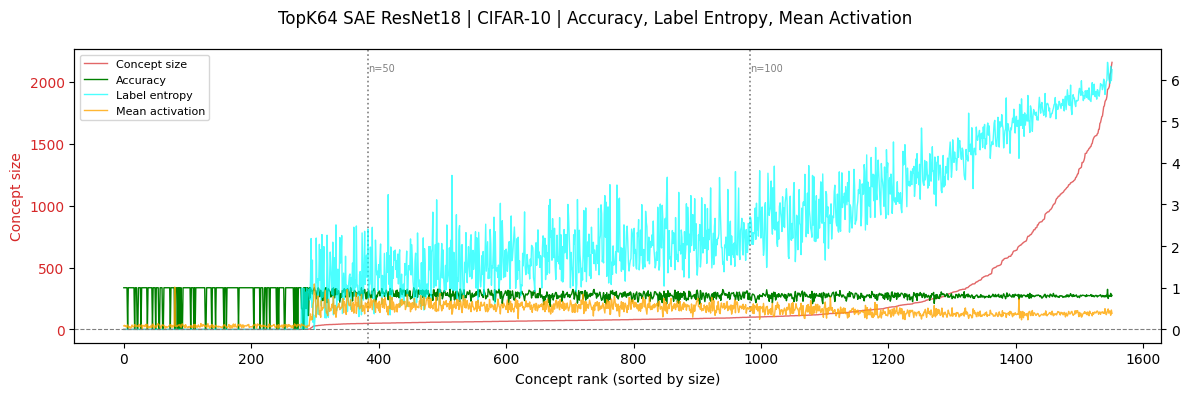

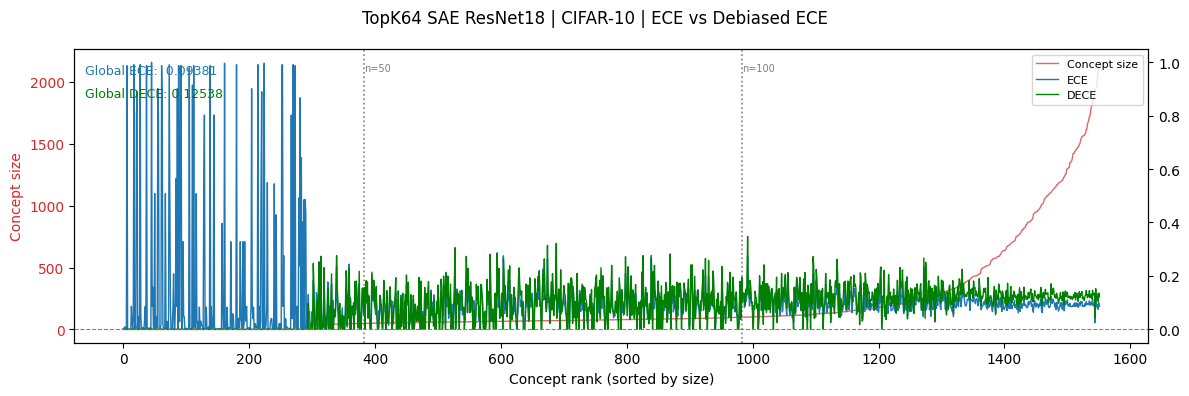

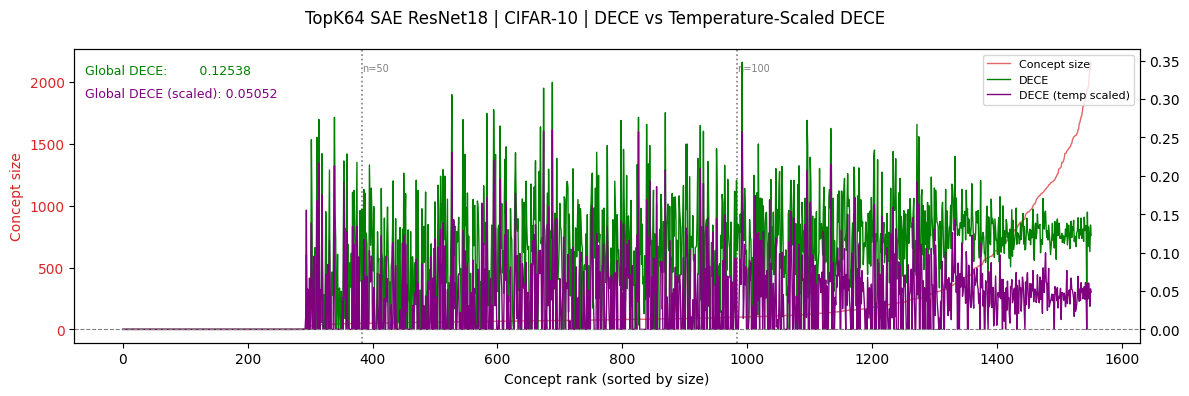

In [12]:
#Define threshold figure and run to generate visualisations

threshold = 0.02

df, cids, test_latents = concept_calibration_analysis(
    sae_model           = topk_sae,
    test_penults        = test_penults_list,
    test_labels         = test_label_list,
    test_logits         = test_logits_list,
    test_logits_scaled  = test_new_logits_list,  # your temperature-scaled logits
    threshold           = threshold,
    model_name          = "TopK64 SAE ResNet18",
    dataset_name        = "CIFAR-10",
)

In [13]:
#Function for 2x2 graphs with metrics

def concept_calibration_analysis_2x2(
    sae_model,
    test_penults,
    test_labels,
    test_logits,
    test_logits_scaled,
    threshold: float = 0.02,
    model_name: str = "SAE",
    dataset_name: str = "Dataset",
    n_bins_max: int = 10,
) -> tuple:

    # --- Extract SAE latents ---
    test_latents = sae_model(
        torch.Tensor(np.array(test_penults))
    )[1].detach().numpy()
    N, C = test_latents.shape

    # --- Softmax probabilities ---
    logits_tensor        = torch.tensor(np.array(test_logits),        dtype=torch.float32)
    logits_scaled_tensor = torch.tensor(np.array(test_logits_scaled), dtype=torch.float32)

    softs        = nn.functional.softmax(logits_tensor,        dim=1).numpy()
    softs_scaled = logits_scaled_tensor.numpy()

    y_pred_te = softs.argmax(axis=1)
    y_te      = np.array(test_labels)

    # --- Concept summary stats ---
    concept_stats = concept_summary_stats(
        sae_model,
        torch.tensor(np.array(test_penults)),
        torch.tensor(np.array(test_labels))
    )

    # --- Per-concept metric lists ---
    concept_sizes        = []
    accs                 = []
    cids                 = []
    cal_gaps             = []
    concept_eces         = []
    concept_deces        = []
    concept_deces_scaled = []
    mean_activations     = []
    label_entropies      = []
    all_confidences      = []
    all_is_correct       = []

    for cid in range(C):
        z           = test_latents[:, cid]
        active_mask = z > threshold

        if active_mask.sum() == 0:
            continue

        y_te_active         = y_te[active_mask]
        y_pred_active       = y_pred_te[active_mask]
        probs_active        = softs[active_mask]
        probs_scaled_active = softs_scaled[active_mask]

        concept_size = active_mask.sum()
        acc          = accuracy_score(y_te_active, y_pred_active)
        confidences  = np.max(probs_active, axis=1)
        is_correct   = (np.argmax(probs_active, axis=1) == y_te_active).astype(int)

        n_bins = min(20, max(3, concept_size // 15))

        # Regular ECE
        sorted_idx = np.argsort(confidences)
        bins       = np.array_split(sorted_idx, n_bins)
        bin_errors = []
        for b in bins:
            if len(b) == 0:
                continue
            bin_errors.append(abs(is_correct[b].mean() - confidences[b].mean()))
        ece = np.mean(bin_errors)

        # Debiased ECE — unscaled
        dece = debiased_ece(confidences, is_correct)

        # Debiased ECE — scaled
        confidences_scaled = np.max(probs_scaled_active, axis=1)
        is_correct_scaled  = (
            np.argmax(probs_scaled_active, axis=1) == y_te_active
        ).astype(int)
        dece_scaled = debiased_ece(confidences_scaled, is_correct_scaled)

        concept_sizes.append(concept_size)
        accs.append(acc)
        cids.append(cid)
        cal_gaps.append(confidences.mean() - acc)
        concept_eces.append(ece)
        concept_deces.append(dece)
        concept_deces_scaled.append(dece_scaled)
        mean_activations.append(z[active_mask].mean())
        label_entropies.append(concept_stats[cid]['label_entropy'])
        all_confidences.extend(confidences)
        all_is_correct.extend(is_correct)

    # --- Build dataframe ---
    df = pd.DataFrame({
        "concept_id":       cids,
        "concept_size":     concept_sizes,
        "accuracy":         accs,
        "cal_gap":          cal_gaps,
        "ece":              concept_eces,
        "dece":             concept_deces,
        "dece_scaled":      concept_deces_scaled,
        "mean_activations": mean_activations,
        "label_entropies":  label_entropies,
    })
    df = df.sort_values("concept_size").reset_index(drop=True)

    title_prefix = f"{model_name} | {dataset_name}"

    # ------------------------------------------------------------------ #
    # 2x2 plot                                                            #
    # ------------------------------------------------------------------ #
    metrics = [
        ("label_entropies",  "Label Entropy",   "cyan"),
        ("mean_activations", "Mean Activation", "orange"),
        ("accuracy",         "Accuracy",        "green"),
        ("dece",             "Debiased ECE",    "tab:blue"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f"{title_prefix} | Per-concept metrics (sorted by concept size)",
                 fontsize=13)

    for ax1, (col, label, color) in zip(axes.flatten(), metrics):

        # Left axis — concept size
        line_size, = ax1.plot(
            df["concept_size"].values,
            color="tab:red", linewidth=1.0, alpha=0.7, label="Concept size"
        )
        ax1.set_xlabel("Concept rank (sorted by size)", fontsize=9)
        ax1.set_ylabel("Concept size", color="tab:red", fontsize=9)
        ax1.tick_params(axis="y", labelcolor="tab:red")
        ax1.set_title(label, fontsize=10)

        # Right axis — metric
        ax2 = ax1.twinx()
        line_metric, = ax2.plot(
            df[col].values,
            color=color, linewidth=1.0, label=label
        )
        ax2.axhline(0, color="gray", linestyle="--", linewidth=0.8)
        ax2.set_ylabel(label, color=color, fontsize=9)
        ax2.tick_params(axis="y", labelcolor=color)

        # Vertical threshold lines
        for thresh_size, thresh_label in [(50, "n=50"), (3000, "n=3000")]:
            crossing = df[df["concept_size"] >= thresh_size].index.min()
            if not pd.isna(crossing):
                ax1.axvline(x=crossing, color="gray", linestyle=":", linewidth=1.2)
                ax1.text(crossing + 0.5, ax1.get_ylim()[1] * 0.95,
                         thresh_label, fontsize=7, color="gray", va="top")

        # Legend
        ax2.legend(
            handles=[line_size, line_metric],
            labels=["Concept size", label],
            loc="upper left", fontsize=8
        )

    fig.tight_layout()
    plt.show()

    return df, cids, test_latents, concept_sizes

/var/folders/bf/rq2mjd6n1jx6k1rs25gv2hxh0000gn/T/ipykernel_31162/1448022514.py:695: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  std = float(numeric_labels[active_mask].std())
/var/folders/bf/rq2mjd6n1jx6k1rs25gv2hxh0000gn/T/ipykernel_31162/1110175753.py:36: RuntimeWarning: invalid value encountered in sqrt
  return max(0.0, np.sqrt(ece)) #We return sqrt(ece)
/var/folders/bf/rq2mjd6n1jx6k1rs25gv2hxh0000gn/T/ipykernel_31162/1110175753.py:36: RuntimeWarning: invalid value encountered in sqrt
  return max(0.0, np.sqrt(ece)) #We return sqrt(ece)
/var/folders/bf/rq2mjd6n1jx6k1rs25gv2hxh0000gn/T/ipykernel_31162/1110175753.py:36: RuntimeWarning: invalid value encountered in sqrt
  return max(0.0, np.sqrt(ece)) #We return sqrt(ece)
/var/folders/bf/rq2mjd6n1jx6k1rs25gv2hxh0000gn/T/ip

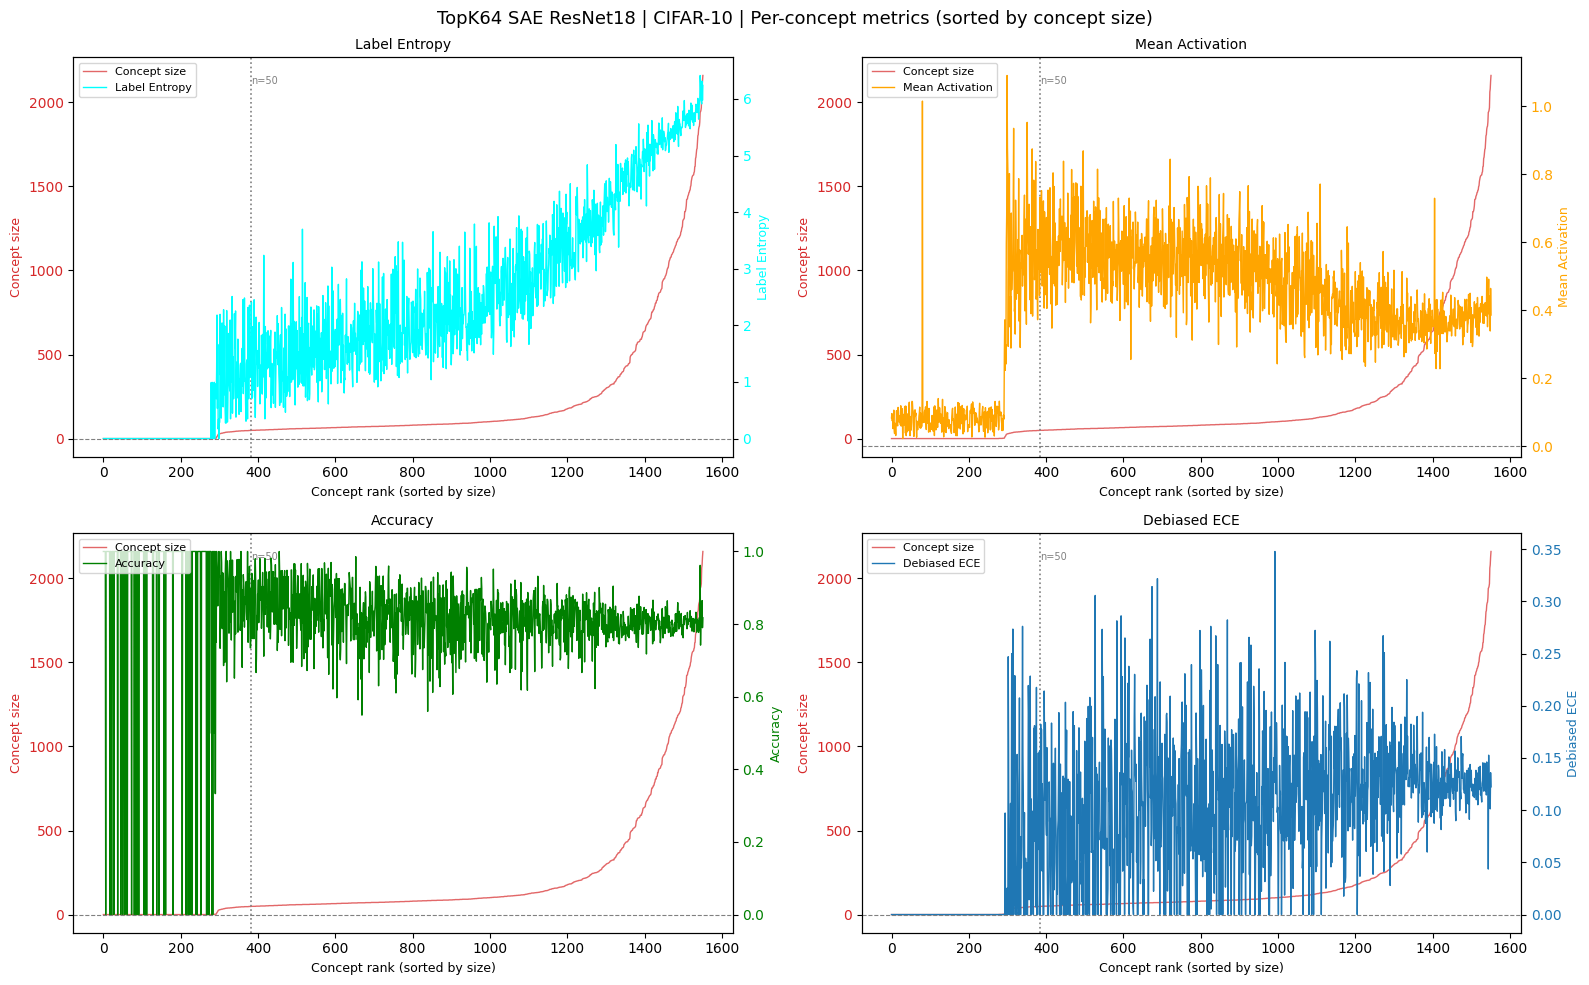

In [14]:
#Define threshold and apply to 2x2 metrics visualisation function call

threshold = 0.02

df, cids, test_latents, concept_sizes = concept_calibration_analysis_2x2(
    sae_model           = topk_sae,
    test_penults        = test_penults_list,
    test_labels         = test_label_list,
    test_logits         = test_logits_list,
    test_logits_scaled  = test_new_logits_list,  # your temperature-scaled logits
    threshold           = threshold,
    model_name          = "TopK64 SAE ResNet18",
    dataset_name        = "CIFAR-10",
)

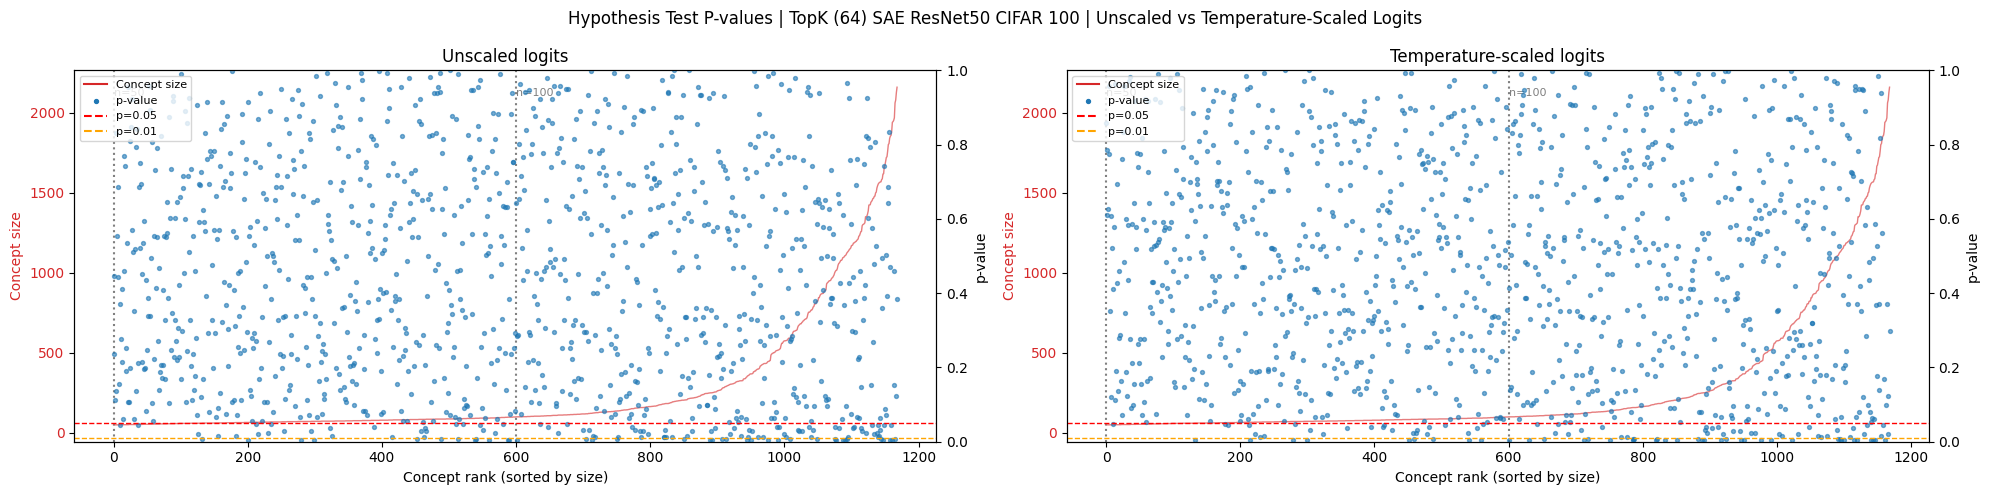

In [15]:
#Correct initial test code - scatter plot of p-values, arranged by concept size


import matplotlib.lines as mlines
from concept_calibration_test import concept_calibration_test

y_te = np.array(test_label_list)

# --- Unscaled logits hypothesis test ---
results_unscaled = []
softs_unscaled = nn.functional.softmax(
    torch.tensor(np.array(test_logits_list), dtype=torch.float32), dim=1
).numpy()


concept_size_lookup = dict(zip(cids, concept_sizes))
filtered_cids = [
    cid for cid in cids
    if 50 <= concept_size_lookup[cid] <= 3000
]
for cid in filtered_cids:
    z               = test_latents[:, cid]
    concept_indices = np.where(z > threshold)[0]

    try:
        result = concept_calibration_test(
            concept_indices=concept_indices,
            probs=softs_unscaled,
            y_true=y_te,
            m=500,
            max_concept_sample_size=1000,
            epsilon=0.05,
            random_state=42,
            return_null_distribution=False,
        )
        results_unscaled.append({
            "concept_id":  cid,
            "concept_ece": result["concept_ece"],
            "p_value":     result["p_value"],
            "null_median": result["null_percentiles"][50],
        })
    except ValueError:
        results_unscaled.append({
            "concept_id":  cid,
            "concept_ece": np.nan,
            "p_value":     np.nan,
            "null_median": np.nan,
        })

# --- Scaled logits hypothesis test ---
results_scaled = []
softs_scaled = np.array(test_new_logits_list)

for cid in filtered_cids:
    z               = test_latents[:, cid]
    concept_indices = np.where(z > threshold)[0]
    try:
        result = concept_calibration_test(
            concept_indices=concept_indices,
            probs=softs_scaled,
            y_true=y_te,
            m=500,
            max_concept_sample_size=1000,
            epsilon=0.05,
            random_state=42,
            return_null_distribution=False,
        )
        results_scaled.append({
            "concept_id":  cid,
            "concept_ece": result["concept_ece"],
            "p_value":     result["p_value"],
            "null_median": result["null_percentiles"][50],
        })
    except ValueError:
        results_scaled.append({
            "concept_id":  cid,
            "concept_ece": np.nan,
            "p_value":     np.nan,
            "null_median": np.nan,
        })


# --- Build separate dataframes — does not touch existing df ---
df_pvals_unscaled = pd.DataFrame(results_unscaled).rename(columns={
    "concept_ece": "concept_ece_unscaled",
    "p_value":     "p_value_unscaled",
    "null_median": "null_median_unscaled",
})
df_pvals_scaled = pd.DataFrame(results_scaled).rename(columns={
    "concept_ece": "concept_ece_scaled",
    "p_value":     "p_value_scaled",
    "null_median": "null_median_scaled",
})

# Merge both into one new dataframe, keeping concept_size from existing df
df_hypothesis = df[["concept_id", "concept_size"]].merge(
    df_pvals_unscaled, on="concept_id"
).merge(
    df_pvals_scaled, on="concept_id"
).sort_values("concept_size").reset_index(drop=True)

# --- Plot ---
def _add_threshold_lines(ax1, df_plot):
    for threshold_size, label in [(50, "n=50"), (100, "n=100")]:
        crossing = df_plot[df_plot["concept_size"] >= threshold_size].index.min()
        if not pd.isna(crossing):
            ax1.axvline(x=crossing, color="gray", linestyle=":", linewidth=1.5)
            ax1.text(crossing + 0.5, ax1.get_ylim()[1] * 0.95,
                     label, fontsize=8, color="gray", va="top")

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(20, 5))
fig.suptitle("Hypothesis Test P-values | TopK (64) SAE ResNet50 CIFAR 100 | Unscaled vs Temperature-Scaled Logits")

for ax1, p_value_col, subtitle in [
    (ax_left,  "p_value_unscaled", "Unscaled logits"),
    (ax_right, "p_value_scaled",   "Temperature-scaled logits"),
]:
    ax1.set_xlabel("Concept rank (sorted by size)")
    ax1.set_ylabel("Concept size", color="tab:red")
    ax1.plot(df_hypothesis["concept_size"].values,
             color="tab:red", linewidth=1.0, alpha=0.6)
    ax1.tick_params(axis="y", labelcolor="tab:red")
    ax1.set_title(subtitle)

    ax2 = ax1.twinx()
    ax2.set_ylabel("p-value")
    ax2.scatter(
        range(len(df_hypothesis)),
        df_hypothesis[p_value_col].values,
        color="tab:blue", s=8, alpha=0.6
    )
    ax2.axhline(0.05, color="red",    linestyle="--", linewidth=1.0, label="p=0.05")
    ax2.axhline(0.01, color="orange", linestyle="--", linewidth=1.0, label="p=0.01")
    ax2.set_ylim(0, 1)

    _add_threshold_lines(ax1, df_hypothesis)

    # Legend
    line_size   = ax1.plot([], [], color="tab:red",  label="Concept size")[0]
    scatter_p   = ax2.scatter([], [], color="tab:blue", s=8, label="p-value")
    line_05     = mlines.Line2D([], [], color="red",    linestyle="--", label="p=0.05")
    line_01     = mlines.Line2D([], [], color="orange", linestyle="--", label="p=0.01")
    ax2.legend(handles=[line_size, scatter_p, line_05, line_01],
               loc="upper left", fontsize=8)

fig.tight_layout()
plt.show()

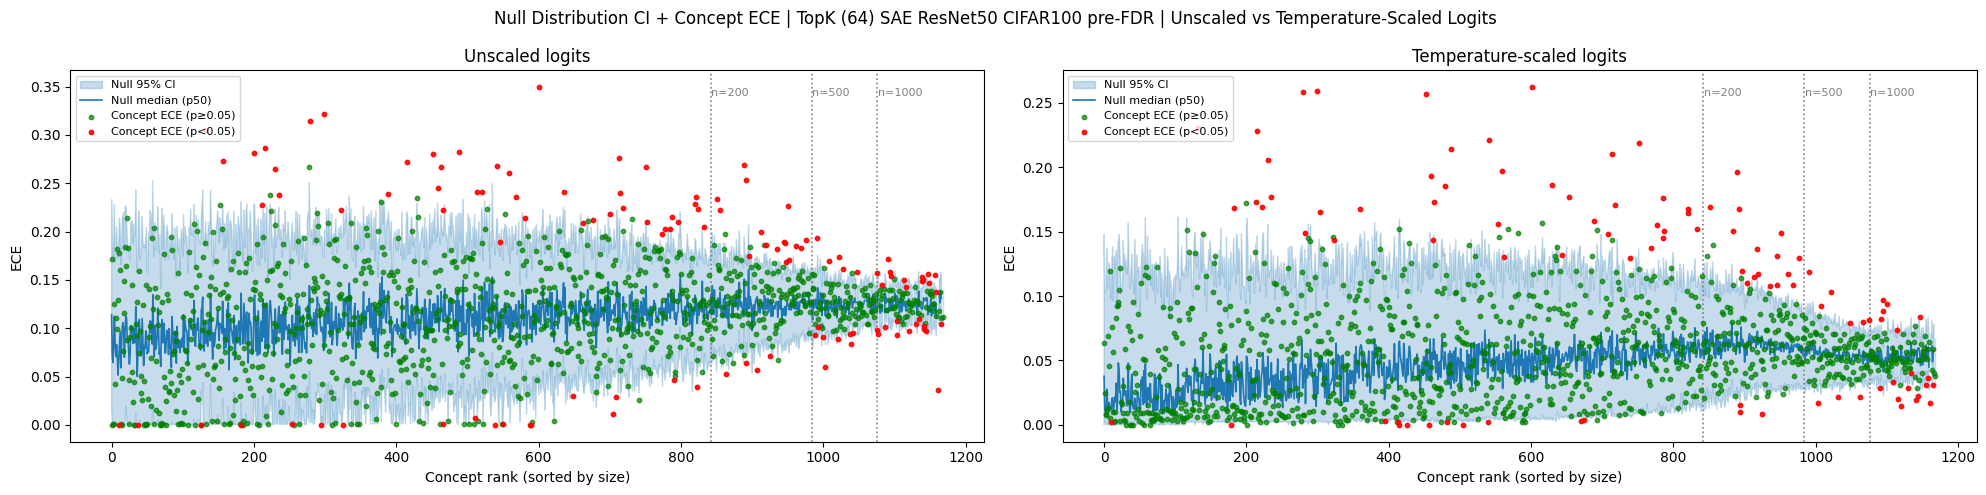

In [16]:
# --- Rerun with return_null_distribution=True to get percentiles ---
results_unscaled = []
results_scaled   = []

for results_list, softs_input in [
    (results_unscaled, softs_unscaled),
    (results_scaled,   softs_scaled),
]:
    for cid in cids:
        # --- Filter by concept size ---
        if not (50 <= concept_size_lookup[cid] <= 3000):
            continue

        z               = test_latents[:, cid]
        concept_indices = np.where(z > threshold)[0]
        try:
            result = concept_calibration_test(
                concept_indices=concept_indices,
                probs=softs_input,
                y_true=y_te,
                m=500,
                max_concept_sample_size=1000,
                epsilon=0.05,
                random_state=42,
                return_null_distribution=True,   # needed for CI
            )
            results_list.append({
                "concept_id":   cid,
                "concept_ece":  result["concept_ece"],
                "p_value":      result["p_value"],
                "null_median":  result["null_percentiles"][50],
                "null_ci_low":  result["null_percentiles"][5],   # 95% CI lower
                "null_ci_high": result["null_percentiles"][95],  # 95% CI upper
            })
        except ValueError:
            results_list.append({
                "concept_id":   cid,
                "concept_ece":  np.nan,
                "p_value":      np.nan,
                "null_median":  np.nan,
                "null_ci_low":  np.nan,
                "null_ci_high": np.nan,
            })

# --- Rebuild df_hypothesis ---
df_pvals_unscaled = pd.DataFrame(results_unscaled).rename(columns={
    "concept_ece":  "concept_ece_unscaled",
    "p_value":      "p_value_unscaled",
    "null_median":  "null_median_unscaled",
    "null_ci_low":  "null_ci_low_unscaled",
    "null_ci_high": "null_ci_high_unscaled",
})
df_pvals_scaled = pd.DataFrame(results_scaled).rename(columns={
    "concept_ece":  "concept_ece_scaled",
    "p_value":      "p_value_scaled",
    "null_median":  "null_median_scaled",
    "null_ci_low":  "null_ci_low_scaled",
    "null_ci_high": "null_ci_high_scaled",
})

df_hypothesis = df[["concept_id", "concept_size"]].merge(
    df_pvals_unscaled, on="concept_id"
).merge(
    df_pvals_scaled, on="concept_id"
).sort_values("concept_size").reset_index(drop=True)

x = np.arange(len(df_hypothesis))

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(20, 5))
fig.suptitle("Null Distribution CI + Concept ECE | TopK (64) SAE ResNet50 CIFAR100 pre-FDR | Unscaled vs Temperature-Scaled Logits")

for ax, ece_col, median_col, ci_low_col, ci_high_col, pval_col, subtitle in [
    (
        axes[0],
        "concept_ece_unscaled",
        "null_median_unscaled",
        "null_ci_low_unscaled",
        "null_ci_high_unscaled",
        "p_value_unscaled",
        "Unscaled logits",
    ),
    (
        axes[1],
        "concept_ece_scaled",
        "null_median_scaled",
        "null_ci_low_scaled",
        "null_ci_high_scaled",
        "p_value_scaled",
        "Temperature-scaled logits",
    ),
]:
    ax.set_title(subtitle)
    ax.set_xlabel("Concept rank (sorted by size)")
    ax.set_ylabel("ECE")

    # 95% CI as faded band
    ax.fill_between(
        x,
        df_hypothesis[ci_low_col].values,
        df_hypothesis[ci_high_col].values,
        alpha=0.25,
        color="tab:blue",
        label="Null 95% CI",
    )

    # Null median as line
    ax.plot(
        x,
        df_hypothesis[median_col].values,
        color="tab:blue",
        linewidth=1.2,
        label="Null median (p50)",
    )

    # Concept ECE as dots, colored by significance
    p_values    = df_hypothesis[pval_col].values
    ece_vals    = df_hypothesis[ece_col].values
    valid       = ~np.isnan(p_values) & ~np.isnan(ece_vals)

    sig_mask    = valid & (p_values < 0.05)
    nonsig_mask = valid & (p_values >= 0.05)

    ax.scatter(x[nonsig_mask], ece_vals[nonsig_mask],
               color="green",  s=10, alpha=0.7, zorder=3,
               label="Concept ECE (p≥0.05)")
    ax.scatter(x[sig_mask],    ece_vals[sig_mask],
               color="red",    s=10, alpha=0.9, zorder=4,
               label="Concept ECE (p<0.05)")

    # Vertical threshold lines
    for threshold_size, thresh_label in [(200, "n=200"), (500, "n=500"), (1000, "n=1000")]:
        crossing = df_hypothesis[
            df_hypothesis["concept_size"] >= threshold_size
        ].index.min()
        if not pd.isna(crossing):
            ax.axvline(x=crossing, color="gray", linestyle=":", linewidth=1.2)
            ax.text(crossing + 0.5, ax.get_ylim()[1] * 0.95,
                    thresh_label, fontsize=8, color="gray", va="top")

    ax.legend(loc="upper left", fontsize=8)

fig.tight_layout()
plt.show()

In [17]:
p_values_scaled = []

for r in results_scaled:
    p_values_scaled.append(r['p_value'])


In [18]:
p_values_unscaled = []

for r in results_unscaled:
    p_values_unscaled.append(r['p_value'])

In [19]:
from statsmodels.stats.multitest import multipletests

pvals = np.array(p_values_unscaled)

reject_unsc, qvals, _, _ = multipletests(
    pvals,
    alpha=0.05,
    method="fdr_bh"
)

print(reject_unsc) # True = significant after FDR correction
print(qvals) # adjusted p-values, often called q-values
print(sum(reject_unsc))

[False False False ... False False False]
[nan nan nan ... nan nan nan]
0


In [20]:
pvals = np.array(p_values_scaled)

reject_sc, qvals, _, _ = multipletests(
    pvals,
    alpha=0.05,
    method="fdr_bh"
)

print(sum(reject_sc))

0


In [44]:
sum(reject_unsc) - sum(reject_sc)

np.int64(17)

In [21]:
#Manually run FDR correction at different alpha levels - note that visualisation is done in next block

from statsmodels.stats.multitest import multipletests

# Apply BH FDR correction
p_values = df_hypothesis["p_value_unscaled"].values
p_values_scaled = df_hypothesis["p_value_scaled"].values

# Returns: reject, p_corrected, alpha_sidak, alpha_bonf
reject_unscaled, p_fdr_unscaled, _, _ = multipletests(
    p_values,
    alpha=0.05,
    method="fdr_bh",
)
reject_scaled, p_fdr_scaled, _, _ = multipletests(
    p_values_scaled,
    alpha=0.05,
    method="fdr_bh",
)

# Add to df_hypothesis
df_hypothesis["p_fdr_unscaled"] = p_fdr_unscaled
df_hypothesis["p_fdr_scaled"]   = p_fdr_scaled
df_hypothesis["reject_unscaled"] = reject_unscaled
df_hypothesis["reject_scaled"]   = reject_scaled

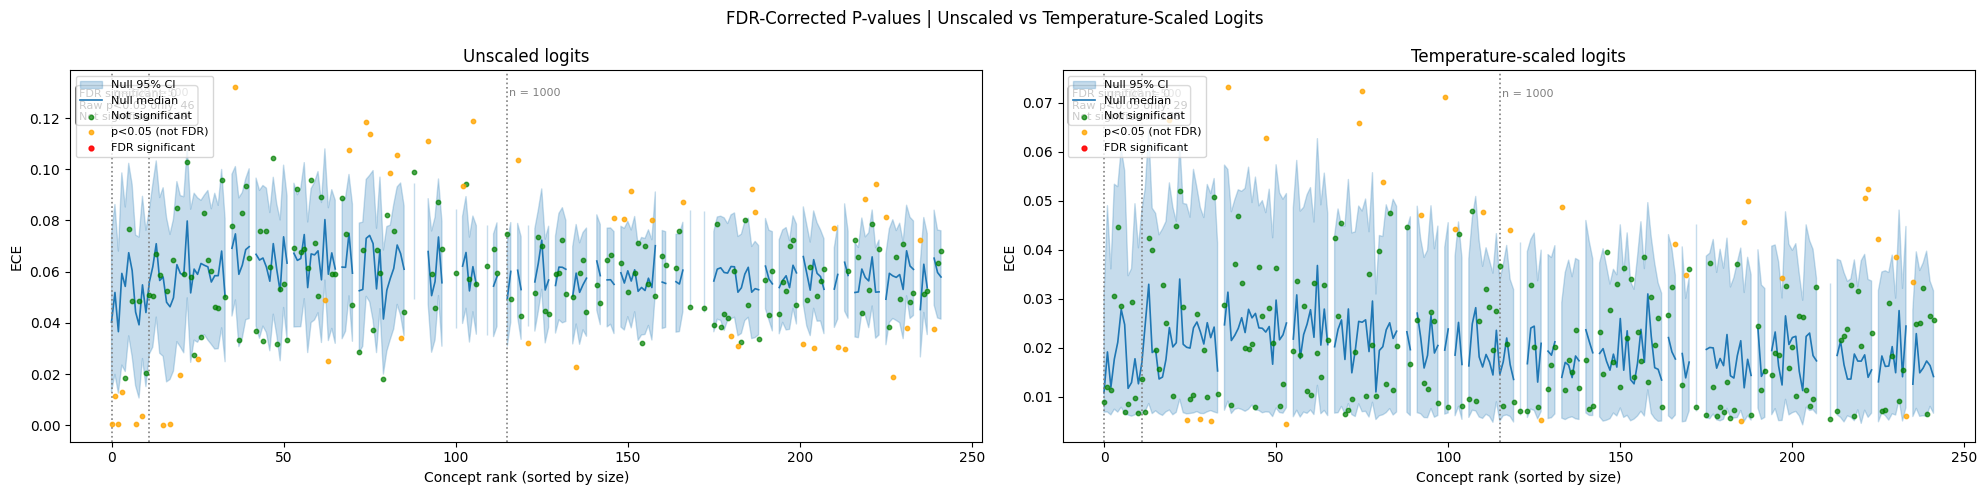

In [215]:
#Visualize FDR corrected p-values together with p-values prior to FDR correction

fig, axes = plt.subplots(1, 2, figsize=(20, 5))
fig.suptitle("FDR-Corrected P-values | Unscaled vs Temperature-Scaled Logits")

for ax, ece_col, median_col, ci_low_col, ci_high_col, \
    pval_col, fdr_col, reject_col, subtitle in [
    (
        axes[0],
        "concept_ece_unscaled",
        "null_median_unscaled",
        "null_ci_low_unscaled",
        "null_ci_high_unscaled",
        "p_value_unscaled",
        "p_fdr_unscaled",
        "reject_unscaled",
        "Unscaled logits",
    ),
    (
        axes[1],
        "concept_ece_scaled",
        "null_median_scaled",
        "null_ci_low_scaled",
        "null_ci_high_scaled",
        "p_value_scaled",
        "p_fdr_scaled",
        "reject_scaled",
        "Temperature-scaled logits",
    ),
]:
    ax.set_title(subtitle)
    ax.set_xlabel("Concept rank (sorted by size)")
    ax.set_ylabel("ECE")

    # 95% CI band
    ax.fill_between(
        x,
        df_hypothesis[ci_low_col].values,
        df_hypothesis[ci_high_col].values,
        alpha=0.25,
        color="tab:blue",
        label="Null 95% CI",
    )

    # Null median
    ax.plot(
        x,
        df_hypothesis[median_col].values,
        color="tab:blue",
        linewidth=1.2,
        label="Null median",
    )

    ece_vals      = df_hypothesis[ece_col].values
    reject        = df_hypothesis[reject_col].values
    p_raw         = df_hypothesis[pval_col].values
    p_fdr         = df_hypothesis[fdr_col].values

    # Three groups:
    # significant after FDR → red
    # significant before FDR but not after → orange (borderline)
    # not significant → green
    sig_fdr      = reject
    sig_raw_only = (~reject) & (p_raw < 0.05)
    nonsig       = (~reject) & (p_raw >= 0.05)

    ax.scatter(x[nonsig],      ece_vals[nonsig],
               color="green",  s=10, alpha=0.7, zorder=3,
               label="Not significant")
    ax.scatter(x[sig_raw_only],ece_vals[sig_raw_only],
               color="orange", s=10, alpha=0.8, zorder=4,
               label="p<0.05 (not FDR)")
    ax.scatter(x[sig_fdr],     ece_vals[sig_fdr],
               color="red",    s=12, alpha=0.9, zorder=5,
               label="FDR significant")

    # Counts as text on plot
    ax.text(0.01, 0.95,
            f"FDR significant: {reject.sum()}\n"
            f"Raw p<0.05 only: {sig_raw_only.sum()}\n"
            f"Not significant: {nonsig.sum()}",
            transform=ax.transAxes, fontsize=8,
            verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

    # Vertical threshold lines
    for threshold_size, thresh_label in [(100, "n=100"), (500, "n=500"), (1000, "n = 1000")]:
        crossing = df_hypothesis[
            df_hypothesis["concept_size"] >= threshold_size
        ].index.min()
        if not pd.isna(crossing):
            ax.axvline(x=crossing, color="gray", linestyle=":", linewidth=1.2)
            ax.text(crossing + 0.5, ax.get_ylim()[1] * 0.95,
                    thresh_label, fontsize=8, color="gray", va="top")

    ax.legend(loc="upper left", fontsize=8)

fig.tight_layout()
plt.show()

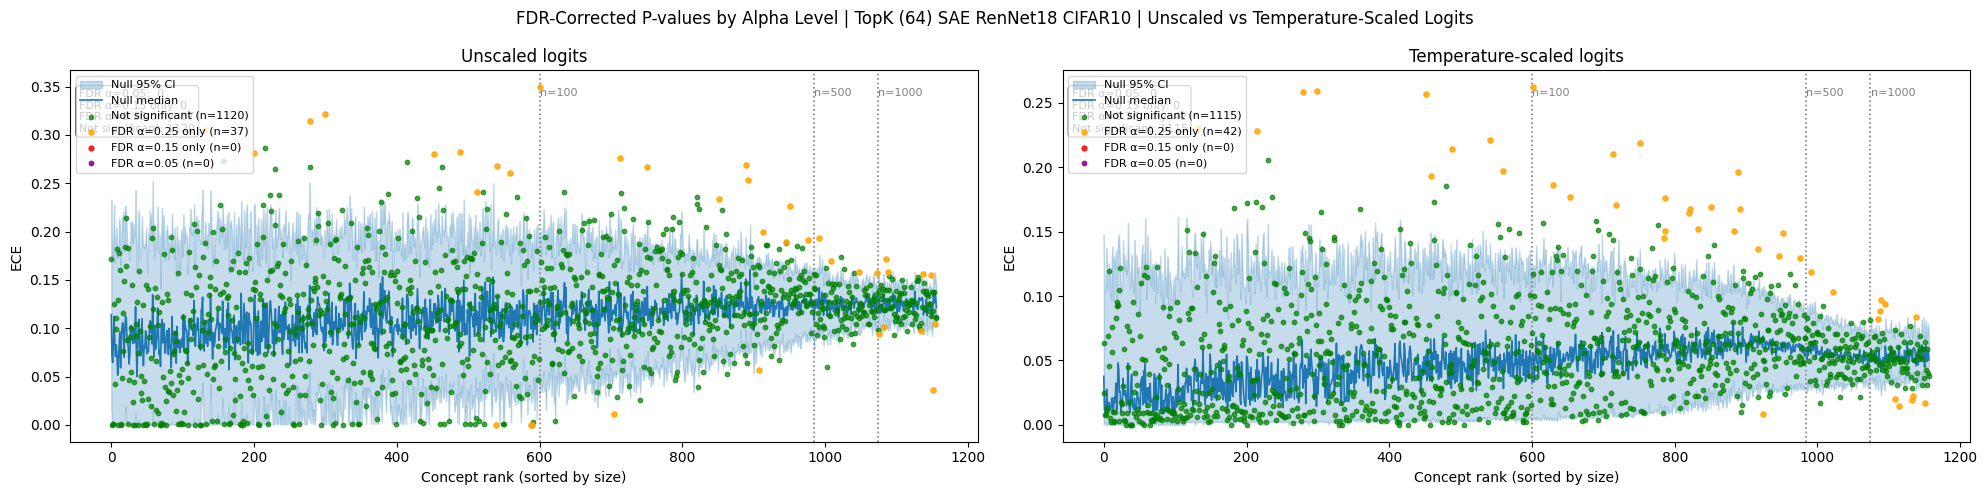

In [22]:
#Visualization for different levels of FDR alpha together in one graph

from statsmodels.stats.multitest import multipletests

# --- Single source of truth for alpha levels ---
# Change these and everything updates automatically
alphas = [0.05, 0.15, 0.25]  # most stringent first

# --- Compute FDR rejection at all alpha levels ---
for pval_col, prefix in [
    ("p_value_unscaled", "unscaled"),
    ("p_value_scaled",   "scaled"),
]:
    # Get non-NaN indices and values
    valid_mask  = df_hypothesis[pval_col].notna()
    valid_index = df_hypothesis.index[valid_mask]
    pvals       = df_hypothesis.loc[valid_index, pval_col].values

    for alpha in alphas:
        reject, qvals, _, _ = multipletests(pvals, alpha=alpha, method="fdr_bh")
        alpha_str = str(alpha).replace(".", "")

        # Initialise column with False/NaN then fill only valid rows
        df_hypothesis[f"reject_{alpha_str}_{prefix}"] = False
        df_hypothesis[f"qval_{alpha_str}_{prefix}"]   = np.nan

        df_hypothesis.loc[valid_index, f"reject_{alpha_str}_{prefix}"] = reject
        df_hypothesis.loc[valid_index, f"qval_{alpha_str}_{prefix}"]   = qvals

valid_both = df_hypothesis["p_value_unscaled"].notna() & df_hypothesis["p_value_scaled"].notna()
df_hypothesis = df_hypothesis[valid_both].reset_index(drop=True)
x = np.arange(len(df_hypothesis))

# --- Colors and labels derived from alphas automatically ---
# One color per alpha level + one for non-significant
dot_colors = ["darkmagenta", "red", "orange"]   # index matches alphas, most stringent first
nonsig_color = "green"

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(20, 5))
fig.suptitle("FDR-Corrected P-values by Alpha Level | TopK (64) SAE RenNet18 CIFAR10 | Unscaled vs Temperature-Scaled Logits")

for ax, ece_col, median_col, ci_low_col, ci_high_col, pval_col, prefix, subtitle in [
    (
        axes[0],
        "concept_ece_unscaled",
        "null_median_unscaled",
        "null_ci_low_unscaled",
        "null_ci_high_unscaled",
        "p_value_unscaled",
        "unscaled",
        "Unscaled logits",
    ),
    (
        axes[1],
        "concept_ece_scaled",
        "null_median_scaled",
        "null_ci_low_scaled",
        "null_ci_high_scaled",
        "p_value_scaled",
        "scaled",
        "Temperature-scaled logits",
    ),
]:
    ax.set_title(subtitle)
    ax.set_xlabel("Concept rank (sorted by size)")
    ax.set_ylabel("ECE")

    # 95% CI band
    ax.fill_between(
        x,
        df_hypothesis[ci_low_col].values,
        df_hypothesis[ci_high_col].values,
        alpha=0.25,
        color="tab:blue",
        label="Null 95% CI",
    )

    # Null median
    ax.plot(
        x,
        df_hypothesis[median_col].values,
        color="tab:blue",
        linewidth=1.2,
        label="Null median",
    )

    ece_vals = df_hypothesis[ece_col].values

    # Build rejection masks from alphas list
    reject_masks = [
        df_hypothesis[f"reject_{str(a).replace('.', '')}_{prefix}"].values
        for a in alphas
    ]

    # Assign each point to most stringent alpha at which it is significant
    # Start with nonsig, then override from least to most stringent
    group = np.full(len(df_hypothesis), -1, dtype=int)  # -1 = not significant
    for i in range(len(alphas) - 1, -1, -1):            # least stringent first
        group[reject_masks[i]] = i

    # Plot non-significant
    nonsig_mask = group == -1
    ax.scatter(x[nonsig_mask], ece_vals[nonsig_mask],
               color=nonsig_color, s=10, alpha=0.7, zorder=3,
               label=f"Not significant (n={nonsig_mask.sum()})")

    # Plot each alpha group from least to most stringent
    for i in range(len(alphas) - 1, -1, -1):
        mask = group == i
        if i == 0:
            # Most stringent — only significant at strictest alpha
            label_str = f"FDR α={alphas[i]} (n={mask.sum()})"
        else:
            label_str = f"FDR α={alphas[i]} only (n={mask.sum()})"
        ax.scatter(x[mask], ece_vals[mask],
                   color=dot_colors[i], s=10 + i*2, alpha=0.85,
                   zorder=4 + (len(alphas) - i),
                   label=label_str)

    # Counts as text on plot
    count_text = "\n".join([
        f"FDR α={alphas[0]}:  {(group==0).sum()}"
    ] + [
        f"FDR α={alphas[i]} only: {(group==i).sum()}"
        for i in range(1, len(alphas))
    ] + [
        f"Not significant: {nonsig_mask.sum()}"
    ])

    ax.text(0.01, 0.95, count_text,
            transform=ax.transAxes, fontsize=8,
            verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

    # Vertical threshold lines
    for threshold_size, thresh_label in [(100, "n=100"), (500, "n=500"), (1000, "n=1000")]:
        crossing = df_hypothesis[
            df_hypothesis["concept_size"] >= threshold_size
        ].index.min()
        if not pd.isna(crossing):
            ax.axvline(x=crossing, color="gray", linestyle=":", linewidth=1.2)
            ax.text(crossing + 0.5, ax.get_ylim()[1] * 0.95,
                    thresh_label, fontsize=8, color="gray", va="top")

    ax.legend(loc="upper left", fontsize=8)

fig.tight_layout()
plt.show()

In [23]:
#View for NaN p-values

print(f"Total rows in df_hypothesis:        {len(df_hypothesis)}")
print(f"Non-NaN p-values unscaled:          {df_hypothesis['p_value_unscaled'].notna().sum()}")
print(f"Non-NaN p-values scaled:            {df_hypothesis['p_value_scaled'].notna().sum()}")
print(f"NaN unscaled:                       {df_hypothesis['p_value_unscaled'].isna().sum()}")
print(f"NaN scaled:                         {df_hypothesis['p_value_scaled'].isna().sum()}")

# Check if NaNs are in the same rows
nan_unscaled = df_hypothesis['p_value_unscaled'].isna()
nan_scaled   = df_hypothesis['p_value_scaled'].isna()
print(f"NaN in both:                        {(nan_unscaled & nan_scaled).sum()}")
print(f"NaN only in unscaled:               {(nan_unscaled & ~nan_scaled).sum()}")
print(f"NaN only in scaled:                 {(~nan_unscaled & nan_scaled).sum()}")

Total rows in df_hypothesis:        1157
Non-NaN p-values unscaled:          1157
Non-NaN p-values scaled:            1157
NaN unscaled:                       0
NaN scaled:                         0
NaN in both:                        0
NaN only in unscaled:               0
NaN only in scaled:                 0


In [24]:
# --- Diagnostic block ---
p_unscaled = df_hypothesis["p_value_unscaled"].dropna().values
p_scaled   = df_hypothesis["p_value_scaled"].dropna().values

print(f"N tests unscaled: {len(p_unscaled)}")
print(f"N tests scaled:   {len(p_scaled)}")

# Raw counts at different thresholds
for thresh in [0.05, 0.15, 0.25]:
    print(f"Raw p<{thresh} unscaled: {np.sum(p_unscaled < thresh)}")
    print(f"Raw p<{thresh} scaled:   {np.sum(p_scaled   < thresh)}")

# FDR counts
from statsmodels.stats.multitest import multipletests
for alpha in [0.05, 0.15, 0.25]:
    r_u, q_u, _, _ = multipletests(p_unscaled, alpha=alpha, method="fdr_bh")
    r_s, q_s, _, _ = multipletests(p_scaled,   alpha=alpha, method="fdr_bh")
    print(f"FDR α={alpha} unscaled: {r_u.sum()}")
    print(f"FDR α={alpha} scaled:   {r_s.sum()}")

# Check q-values vs raw p-values for the "extra" significant ones
r_025, q_025, _, _ = multipletests(p_unscaled, alpha=0.25, method="fdr_bh")
print("\nConcepts significant at FDR 0.25 but raw p > 0.05:")
extra = (r_025) & (p_unscaled >= 0.05)
print(f"Count: {extra.sum()}")
print(f"Their raw p-values: {p_unscaled[extra]}")
print(f"Their q-values:     {q_025[extra]}")

N tests unscaled: 1157
N tests scaled:   1157
Raw p<0.05 unscaled: 121
Raw p<0.05 scaled:   98
Raw p<0.15 unscaled: 266
Raw p<0.15 scaled:   232
Raw p<0.25 unscaled: 380
Raw p<0.25 scaled:   344
FDR α=0.05 unscaled: 0
FDR α=0.05 scaled:   0
FDR α=0.15 unscaled: 0
FDR α=0.15 scaled:   31
FDR α=0.25 unscaled: 37
FDR α=0.25 scaled:   42

Concepts significant at FDR 0.25 but raw p > 0.05:
Count: 0
Their raw p-values: []
Their q-values:     []


=== Unscaled logits ===
Total concepts tested:      1157
Raw p<0.05 significant:     121 (10.5%)
FDR significant (α=0.05): 0 (0.0%)
FDR significant (α=0.15): 0 (0.0%)
FDR significant (α=0.25): 37 (3.2%)

=== Temperature-scaled logits ===
Total concepts tested:      1157
Raw p<0.05 significant:     98 (8.5%)
FDR significant (α=0.05): 0 (0.0%)
FDR significant (α=0.15): 31 (2.7%)
FDR significant (α=0.25): 42 (3.6%)


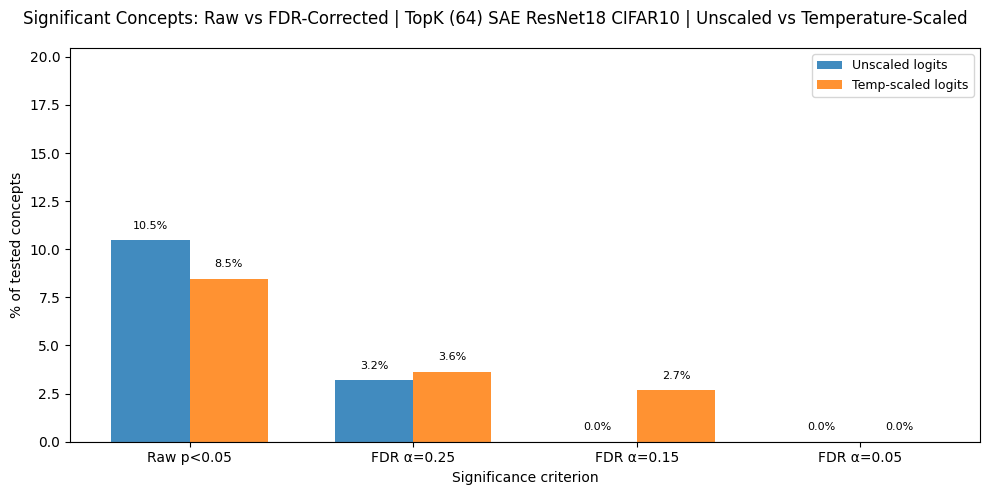

In [25]:
#Comparison between number of pre-FDR p-values and post-FDR p-values as shares of total

from statsmodels.stats.multitest import multipletests
import numpy as np
import matplotlib.pyplot as plt

# --- FDR calculation for multiple alpha levels ---

p_values_unscaled = df_hypothesis["p_value_unscaled"].dropna().values
p_values_scaled   = df_hypothesis["p_value_scaled"].dropna().values
total_unscaled    = len(p_values_unscaled)
total_scaled      = len(p_values_scaled)

alphas = [0.05, 0.15, 0.25]

# Raw p-value counts (no FDR correction)
raw_sig_unscaled = np.sum(p_values_unscaled < 0.05)
raw_sig_scaled   = np.sum(p_values_scaled   < 0.05)

# FDR-corrected counts per alpha
fdr_counts_unscaled = {}
fdr_counts_scaled   = {}

for alpha in alphas:
    reject_unsc, _, _, _ = multipletests(p_values_unscaled, alpha=alpha, method="fdr_bh")
    reject_sc,   _, _, _ = multipletests(p_values_scaled,   alpha=alpha, method="fdr_bh")
    fdr_counts_unscaled[alpha] = int(np.sum(reject_unsc))
    fdr_counts_scaled[alpha]   = int(np.sum(reject_sc))

# Print summary
print("=== Unscaled logits ===")
print(f"Total concepts tested:      {total_unscaled}")
print(f"Raw p<0.05 significant:     {raw_sig_unscaled} ({100*raw_sig_unscaled/total_unscaled:.1f}%)")
for alpha in alphas:
    n = fdr_counts_unscaled[alpha]
    print(f"FDR significant (α={alpha}): {n} ({100*n/total_unscaled:.1f}%)")

print("\n=== Temperature-scaled logits ===")
print(f"Total concepts tested:      {total_scaled}")
print(f"Raw p<0.05 significant:     {raw_sig_scaled} ({100*raw_sig_scaled/total_scaled:.1f}%)")
for alpha in alphas:
    n = fdr_counts_scaled[alpha]
    print(f"FDR significant (α={alpha}): {n} ({100*n/total_scaled:.1f}%)")

# --- Bar chart ---
# 4 bars per cluster:
# 1. Raw p<0.05 (no FDR)
# 2. FDR α=0.25
# 3. FDR α=0.15
# 4. FDR α=0.05


bar_labels = ["Raw p<0.05", "FDR α=0.25", "FDR α=0.15", "FDR α=0.05"]

pct_unscaled = [
    100 * raw_sig_unscaled          / total_unscaled,
    100 * fdr_counts_unscaled[0.25] / total_unscaled,
    100 * fdr_counts_unscaled[0.15] / total_unscaled,
    100 * fdr_counts_unscaled[0.05] / total_unscaled,
]

pct_scaled = [
    100 * raw_sig_scaled          / total_scaled,
    100 * fdr_counts_scaled[0.25] / total_scaled,
    100 * fdr_counts_scaled[0.15] / total_scaled,
    100 * fdr_counts_scaled[0.05] / total_scaled,
]

x         = np.arange(len(bar_labels))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Significant Concepts: Raw vs FDR-Corrected | TopK (64) SAE ResNet18 CIFAR10 | Unscaled vs Temperature-Scaled")

bars_unsc = ax.bar(x - bar_width/2, pct_unscaled, bar_width,
                   label="Unscaled logits",  color="tab:blue",   alpha=0.85)
bars_sc   = ax.bar(x + bar_width/2, pct_scaled,   bar_width,
                   label="Temp-scaled logits", color="tab:orange", alpha=0.85)

# Value labels on top of each bar
for bar in bars_unsc:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%",
            ha="center", va="bottom", fontsize=8)

for bar in bars_sc:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{bar.get_height():.1f}%",
            ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(bar_labels)
ax.set_ylabel("% of tested concepts")
ax.set_xlabel("Significance criterion")
ax.set_ylim(0, max(max(pct_unscaled), max(pct_scaled)) + 10)
ax.legend(fontsize=9)
ax.axhline(0, color="gray", linewidth=0.8)

fig.tight_layout()
plt.show()